# ChemAI: Predict the Cure — Объединённый EDA

Разведочный анализ данных по шести группам молекулярных дескрипторов.

750 обучающих объектов, 214 признаков, 3 таргета: **IC50**, **CC50**, **SI**.
Все удаления признаков применяются к общим `train`/`test` последовательно.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.stats import ks_2samp, spearmanr, f_oneway
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from IPython.display import display
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

SEED = 42
np.random.seed(SEED)

In [2]:
import os
from google.colab import files

# Create 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

print("Please upload 'train.csv' and 'test.csv'.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
    # Move the uploaded file to the 'data/' directory
    os.rename(filename, os.path.join('data', filename))
    print(f'Moved {filename} to data/{filename}')


Please upload 'train.csv' and 'test.csv'.


Saving train_.csv to train_.csv
Saving test_.csv to test_.csv
Saving sample_submission_.csv to sample_submission_.csv
User uploaded file "train_.csv" with length 1359909 bytes
Moved train_.csv to data/train_.csv
User uploaded file "test_.csv" with length 440872 bytes
Moved test_.csv to data/test_.csv
User uploaded file "sample_submission_.csv" with length 15354 bytes
Moved sample_submission_.csv to data/sample_submission_.csv


In [3]:
train = pd.read_csv('data/train_.csv')
test = pd.read_csv('data/test_.csv')


# Нормализация имён таргетов (в исходном датасете — с единицами измерения)
train.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'}, inplace=True)
test.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'}, inplace=True, errors='ignore')

TARGETS = ['IC50', 'CC50', 'SI']
print(f'Train: {train.shape}  Test: {test.shape}')
train.head()

Train: (751, 214)  Test: (250, 211)


,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


## Анализ таргетов

Три целевых переменных: **IC50** (антивирусная активность, мМ), **CC50** (цитотоксичность, мМ), **SI** (индекс селективности = CC50/IC50).

Описательная статистика таргетов:


,IC50,CC50,SI
count,751.0000,751.0000,751.0000
mean,204.5440,577.4261,89.1533
std,370.3679,641.5152,788.8822
min,0.0035,0.7008,0.0115
25%,13.2224,99.9989,1.5000
50%,44.0693,376.5809,4.0000
75%,206.7874,877.5088,17.3725
max,4095.1886,4538.9762,15620.6000


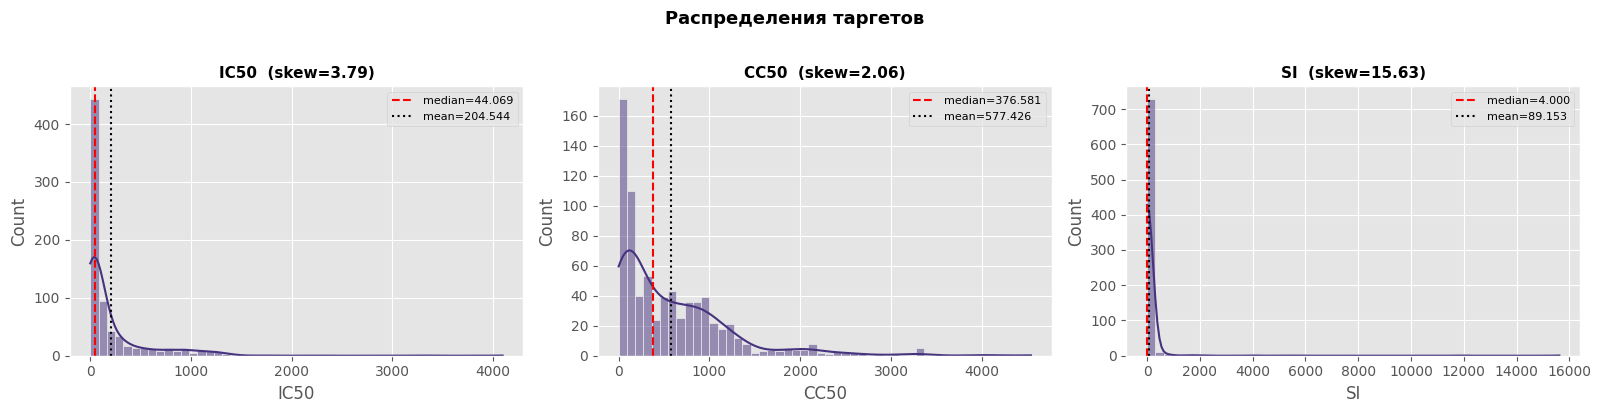


Корреляции между таргетами (Pearson / Spearman):
  IC50 ↔ CC50: Pearson=+0.470, Spearman=+0.600
  IC50 ↔ SI: Pearson=-0.061, Spearman=-0.642
  CC50 ↔ SI: Pearson=-0.006, Spearman=+0.129


In [4]:
# Описательная статистика таргетов
print("Описательная статистика таргетов:")
display(train[TARGETS].describe().round(4))

# Распределения
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, t in zip(axes, TARGETS):
    s = train[t].dropna()
    sns.histplot(s, bins=50, kde=True, ax=ax)
    ax.axvline(s.median(), color='red',   linestyle='--', linewidth=1.5, label=f'median={s.median():.3f}')
    ax.axvline(s.mean(),   color='black', linestyle=':',  linewidth=1.5, label=f'mean={s.mean():.3f}')
    ax.set_title(f'{t}  (skew={s.skew():.2f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Распределения таргетов', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Попарные корреляции таргетов
print("\nКорреляции между таргетами (Pearson / Spearman):")
for t1, t2 in [('IC50','CC50'), ('IC50','SI'), ('CC50','SI')]:
    rp = train[t1].corr(train[t2])
    rs = train[t1].corr(train[t2], method='spearman')
    print(f"  {t1} ↔ {t2}: Pearson={rp:+.3f}, Spearman={rs:+.3f}")

**Ключевые наблюдения по таргетам:**

- **IC50** и **CC50** сильно правосмещены (skew > 2) — большинство молекул имеют высокие значения (слабая активность / низкая токсичность), единицы — очень низкие (высокая активность). Для регрессии рекомендуется log-преобразование.
- **SI** = CC50 / IC50 — производный таргет; его распределение ещё более скошено. Высокий SI означает хорошую селективность (активен против вируса, безопасен для клетки).
- Корреляция IC50 ↔ CC50 умеренная, IC50 ↔ SI отрицательная: более активные молекулы (низкий IC50) как правило более селективны.

In [26]:
# ── Вспомогательные функции ────────────────────────
# Основа: eda_group1_Vadim.ipynb + eda_group3_Pavel.ipynb

def display_columns_info(df, columns=None):
    """Выводит подробную статистику по колонкам."""
    if columns is None:
        columns = df.columns.tolist()
    info_list = []
    for col in columns:
        info_list.append({
            'column': col,
            'dtype': df[col].dtype,
            'missing': df[col].isnull().sum(),
            'missing_pct': df[col].isnull().sum() / len(df) * 100,
            'unique': df[col].nunique(),
            'min': df[col].min() if df[col].dtype in ['float64', 'int64'] else None,
            'max': df[col].max() if df[col].dtype in ['float64', 'int64'] else None,
            'mean': df[col].mean() if df[col].dtype in ['float64', 'int64'] else None,
            'std': df[col].std() if df[col].dtype in ['float64', 'int64'] else None
        })
    info_df = pd.DataFrame(info_list)
    display(info_df)


def interpret_correlation_strength(corr_coef):
    """Интерпретирует силу коэффициента корреляции."""
    abs_corr = abs(corr_coef)
    if abs_corr < 0.1:   return "очень слабая"
    elif abs_corr < 0.3: return "слабая"
    elif abs_corr < 0.5: return "умеренная"
    elif abs_corr < 0.7: return "сильная"
    else:                return "очень сильная"


def interpret_statistical_significance(p_value):
    """Интерпретирует статистическую значимость p-value."""
    if p_value < 0.001:  return "высокозначимо"
    elif p_value < 0.01: return "очень значимо"
    elif p_value < 0.05: return "значимо"
    else:                return "не значимо"


def plot_distributions(df, features, group_name=""):
    """Строит гистограммы распределений для каждого признака."""
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.histplot(df[feat], kde=True, ax=ax)
        ax.set_title(f"{feat}\nSkewness: {df[feat].skew():.2f}", fontsize=9)
        ax.set_xlabel('')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(f'Distributions - {group_name}', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_boxplots(df, features, group_name=""):
    """Строит box plots для обнаружения выбросов."""
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(y=df[feat], ax=ax)
        ax.set_title(feat, fontsize=9)
        ax.set_ylabel('')
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(f'Box Plots (Outliers) - {group_name}', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df, features, targets=None, group_name=""):
    """Строит тепловую карту корреляций признаков и таргетов."""
    if targets is None:
        targets = []
    corr_cols = features + targets
    corr = df[corr_cols].corr()
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    plt.title(f'Correlation Matrix - {group_name}', fontsize=14, fontweight='bold', y=1.02)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    return corr


def print_top_correlations_with_targets(df, features, targets):
    """Топ-5 признаков по |r| с каждым таргетом (Пирсон + Спирмен)."""
    pearson_corr  = df[features + targets].corr()
    spearman_corr = df[features + targets].corr(method='spearman')
    for target in targets:
        other_t = [t for t in targets if t != target]
        p_vals = pearson_corr[target].drop(other_t + [target], errors='ignore')
        s_vals = spearman_corr[target].drop(other_t + [target], errors='ignore')
        top5 = p_vals.abs().sort_values(ascending=False).head(5).index
        print(f"\n{'='*60}")
        print(f"Топ-5 признаков с {target}:")
        print(f"{'='*60}")
        for feat in top5:
            p, s = p_vals[feat], s_vals[feat]
            print(f"  {feat:<35s}  Пирсон={p:+.4f} ({interpret_correlation_strength(p)}), "
                  f"Спирмен={s:+.4f}")


def find_constant_features(df, features):
    """Находит константные признаки (нулевая дисперсия)."""
    return [f for f in features if df[f].std() == 0]


def find_low_variance_features(df, features, threshold=0.01):
    """Находит почти константные признаки с дисперсией ниже порога."""
    sel = VarianceThreshold(threshold=threshold)
    sel.fit(df[features])
    return [features[i] for i in np.where(~sel.get_support())[0]]


def find_highly_correlated_pairs(df, features, threshold=0.95):
    """Находит пары признаков с корреляцией выше порога."""
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = []
    for col in upper.columns:
        for idx in upper.index:
            if upper.loc[col, idx] > threshold:
                high_corr_pairs.append({
                    'feature1': col,
                    'feature2': idx,
                    'correlation': upper.loc[col, idx]
                })
    if not high_corr_pairs:
        return pd.DataFrame(columns=['feature1', 'feature2', 'correlation'])
    return pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)


def detect_drift(train_df, test_df, features, threshold=0.05):
    """Обнаруживает дрифт распределений между train и test (KS-тест)."""
    drift_results = []
    for feat in features:
        ks_stat, p_value = ks_2samp(train_df[feat].dropna(), test_df[feat].dropna())
        drift_results.append({
            'feature': feat,
            'ks_statistic': ks_stat,
            'p_value': p_value,
            'drift': p_value < threshold
        })
    return pd.DataFrame(drift_results)


def analyze_outliers(df, features):
    """Анализирует выбросы методом IQR."""
    outlier_report = []
    for feat in features:
        Q1 = df[feat].quantile(0.25)
        Q3 = df[feat].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feat] < lower_bound) | (df[feat] > upper_bound)]
        outlier_pct = len(outliers) / len(df) * 100
        outlier_report.append({
            'feature': feat,
            'outliers_count': len(outliers),
            'outliers_pct': outlier_pct
        })
    return pd.DataFrame(outlier_report).sort_values('outliers_pct', ascending=False)


print("Вспомогательные функции загружены.")

Вспомогательные функции загружены.


## Группа 1 — Общие молекулярные свойства

Группа включает 27 признаков, описывающих базовые физико-химические и структурные характеристики молекул.

In [6]:
# ── G1: Определение признаков ─────────────────────────────────────────────

GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME = 'Общие молекулярные свойства'

GENERAL_MOLECULAR_PROPERTIES = [
    'MolWt', 'ExactMolWt', 'HeavyAtomMolWt', 'NumValenceElectrons',
    'NumRadicalElectrons', 'MolLogP', 'MolMR', 'TPSA', 'LabuteASA',
    'HeavyAtomCount', 'NHOHCount', 'NOCount', 'NumHAcceptors', 'NumHDonors',
    'NumHeteroatoms', 'NumRotatableBonds', 'RingCount',
    'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings',
    'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings',
    'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings',
    'FractionCSP3'
]

display_columns_info(train, GENERAL_MOLECULAR_PROPERTIES)

,column,dtype,missing,missing_pct,unique,min,max,mean,std
0,MolWt,float64,0,0.0,571,110.156000,904.777000,352.407345,129.071212
1,ExactMolWt,float64,0,0.0,556,110.073165,904.248467,352.081343,128.924918
2,HeavyAtomMolWt,float64,0,0.0,500,100.076000,856.393000,328.389832,124.072354
3,NumValenceElectrons,int64,0,0.0,107,42.000000,350.000000,133.627164,47.173659
4,NumRadicalElectrons,int64,0,0.0,1,0.000000,0.000000,0.000000,0.000000
5,MolLogP,float64,0,0.0,592,-5.750700,12.822200,3.464946,2.137080
6,MolMR,float64,0,0.0,594,28.088500,236.253400,95.384745,34.804886
7,TPSA,float64,0,0.0,282,0.000000,407.500000,61.912783,46.381500
8,LabuteASA,float64,0,0.0,582,46.234269,353.328713,148.466382,53.250937
9,HeavyAtomCount,int64,0,0.0,46,8.000000,63.000000,24.954727,9.206987


In [7]:
# ── G1: Поиск константных и почти константных признаков ───────────────────
constant = find_constant_features(train, GENERAL_MOLECULAR_PROPERTIES)
print(f"Константные признаки (нулевая дисперсия): {constant}")

low_var = find_low_variance_features(train, GENERAL_MOLECULAR_PROPERTIES, threshold=0.01)
print(f"Почти константные признаки (дисперсия < 0.01): {low_var}")

Константные признаки (нулевая дисперсия): ['NumRadicalElectrons']
Почти константные признаки (дисперсия < 0.01): ['NumRadicalElectrons']


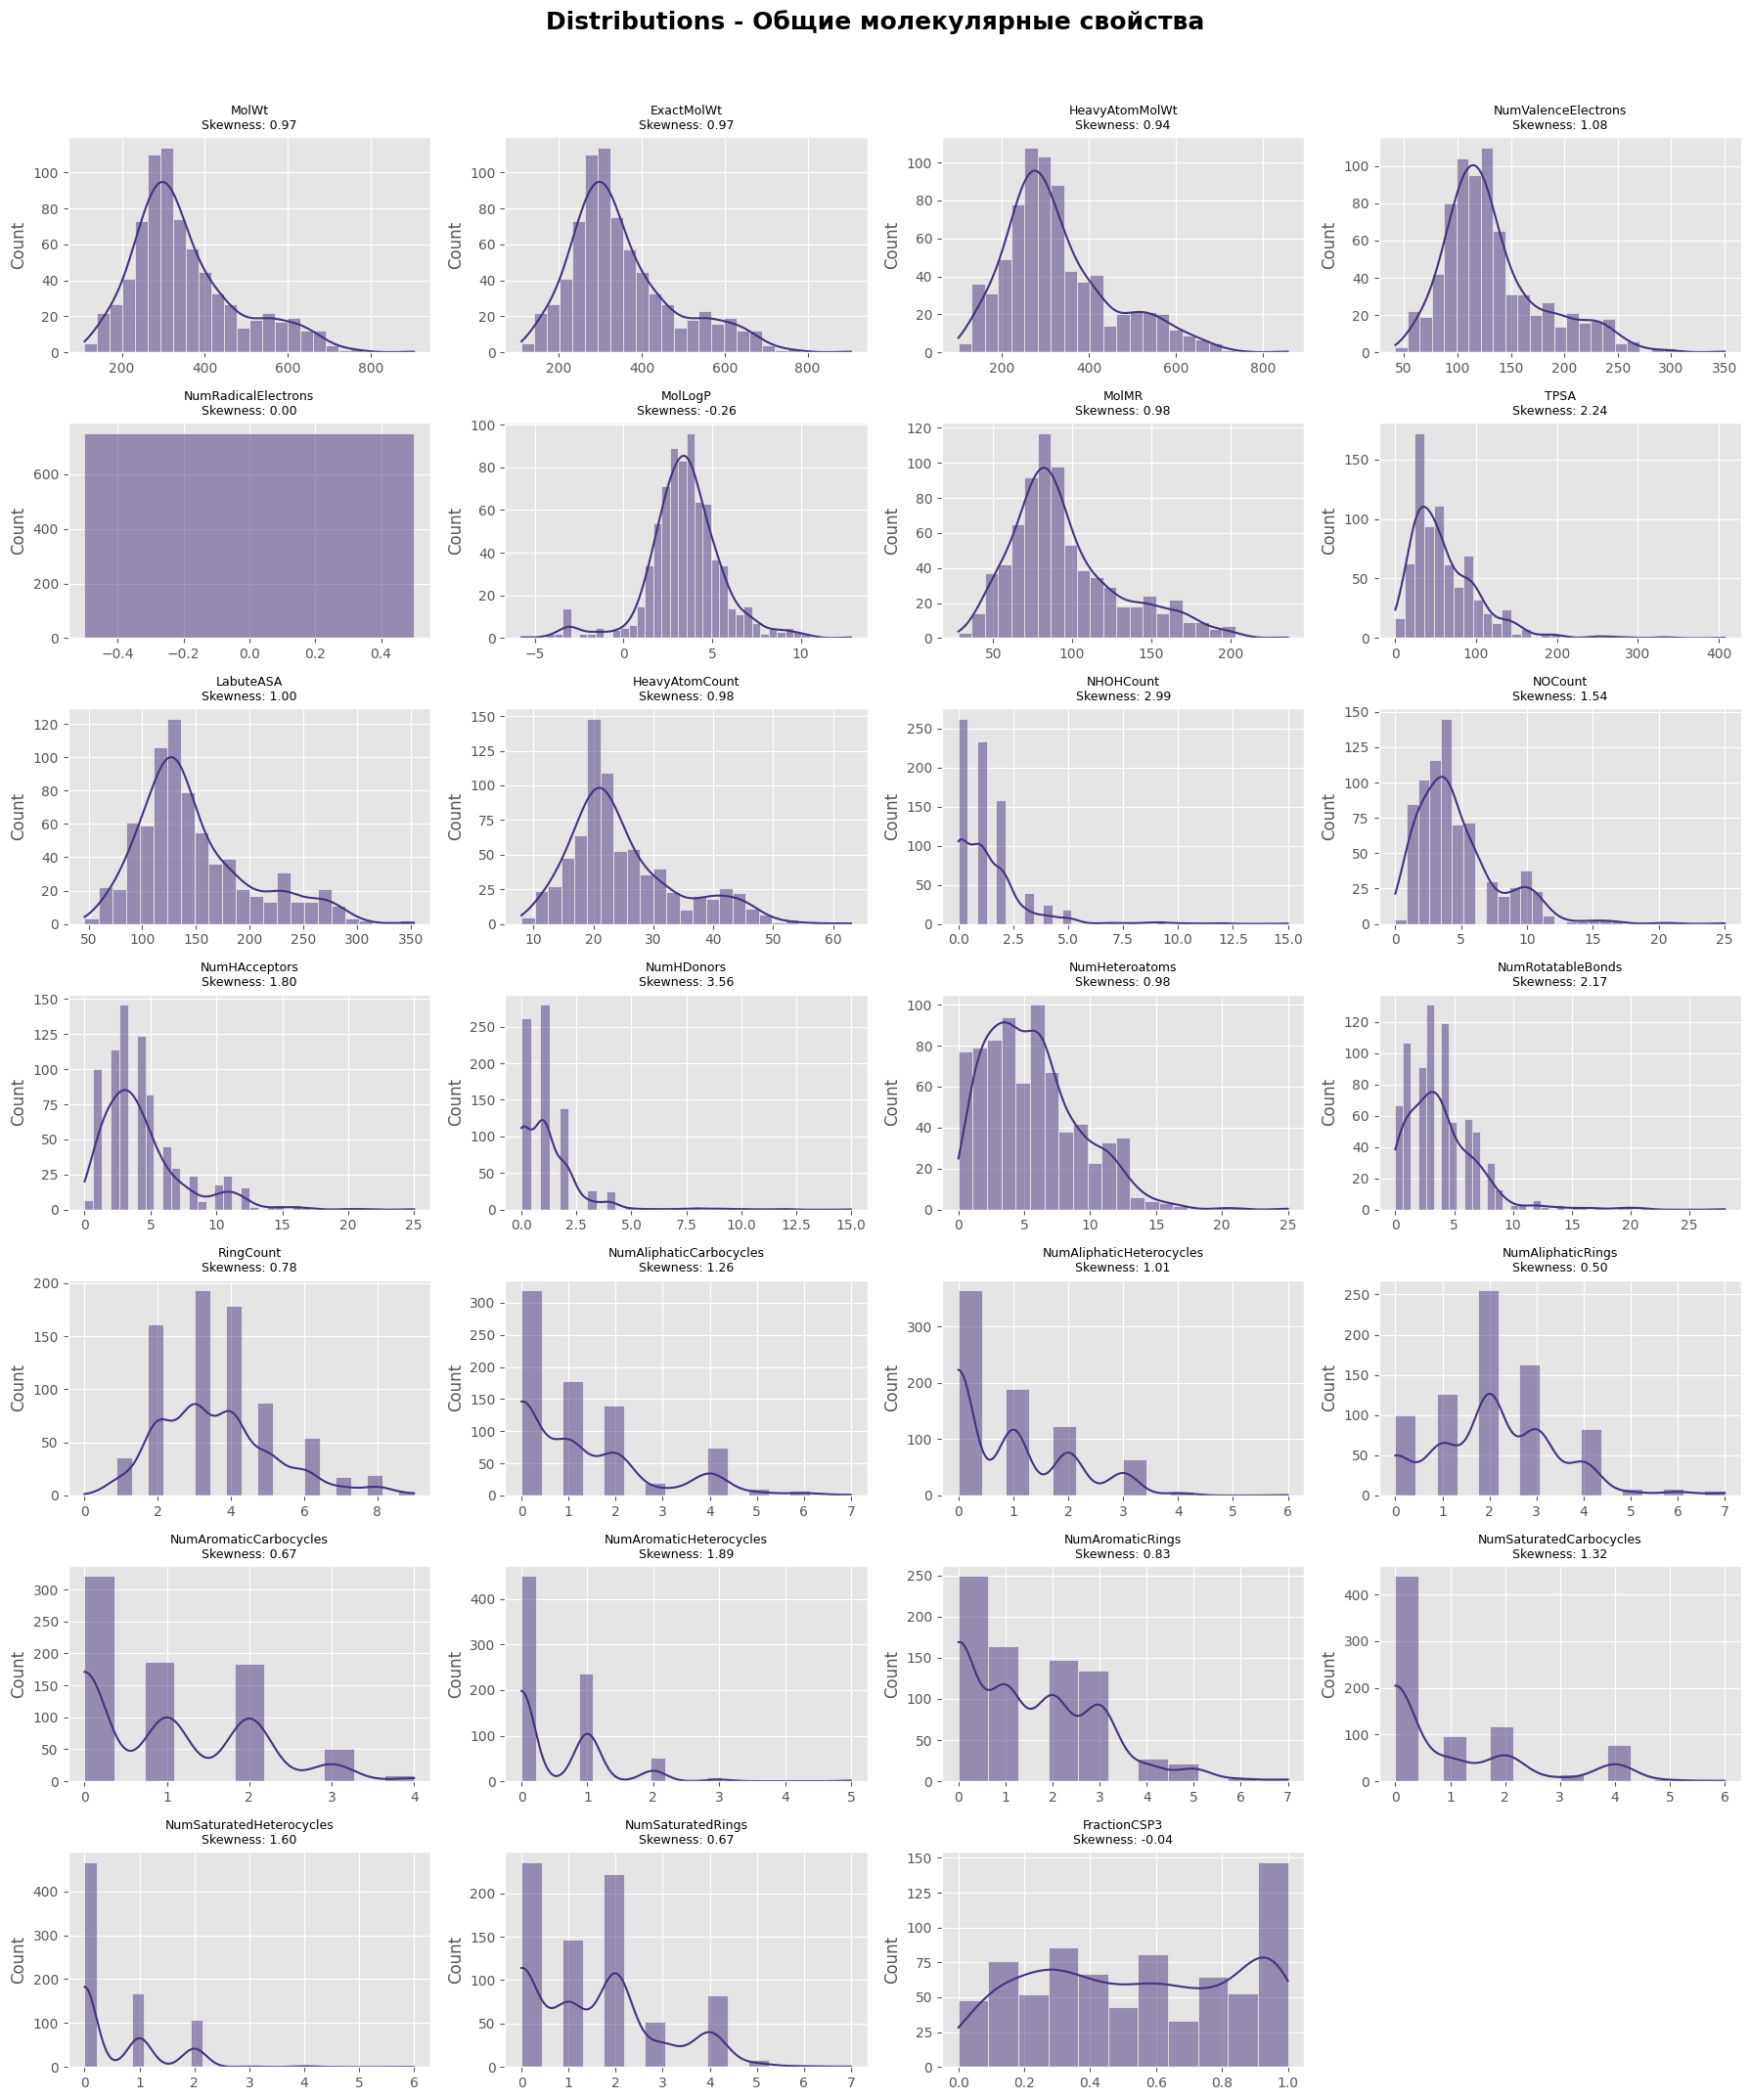

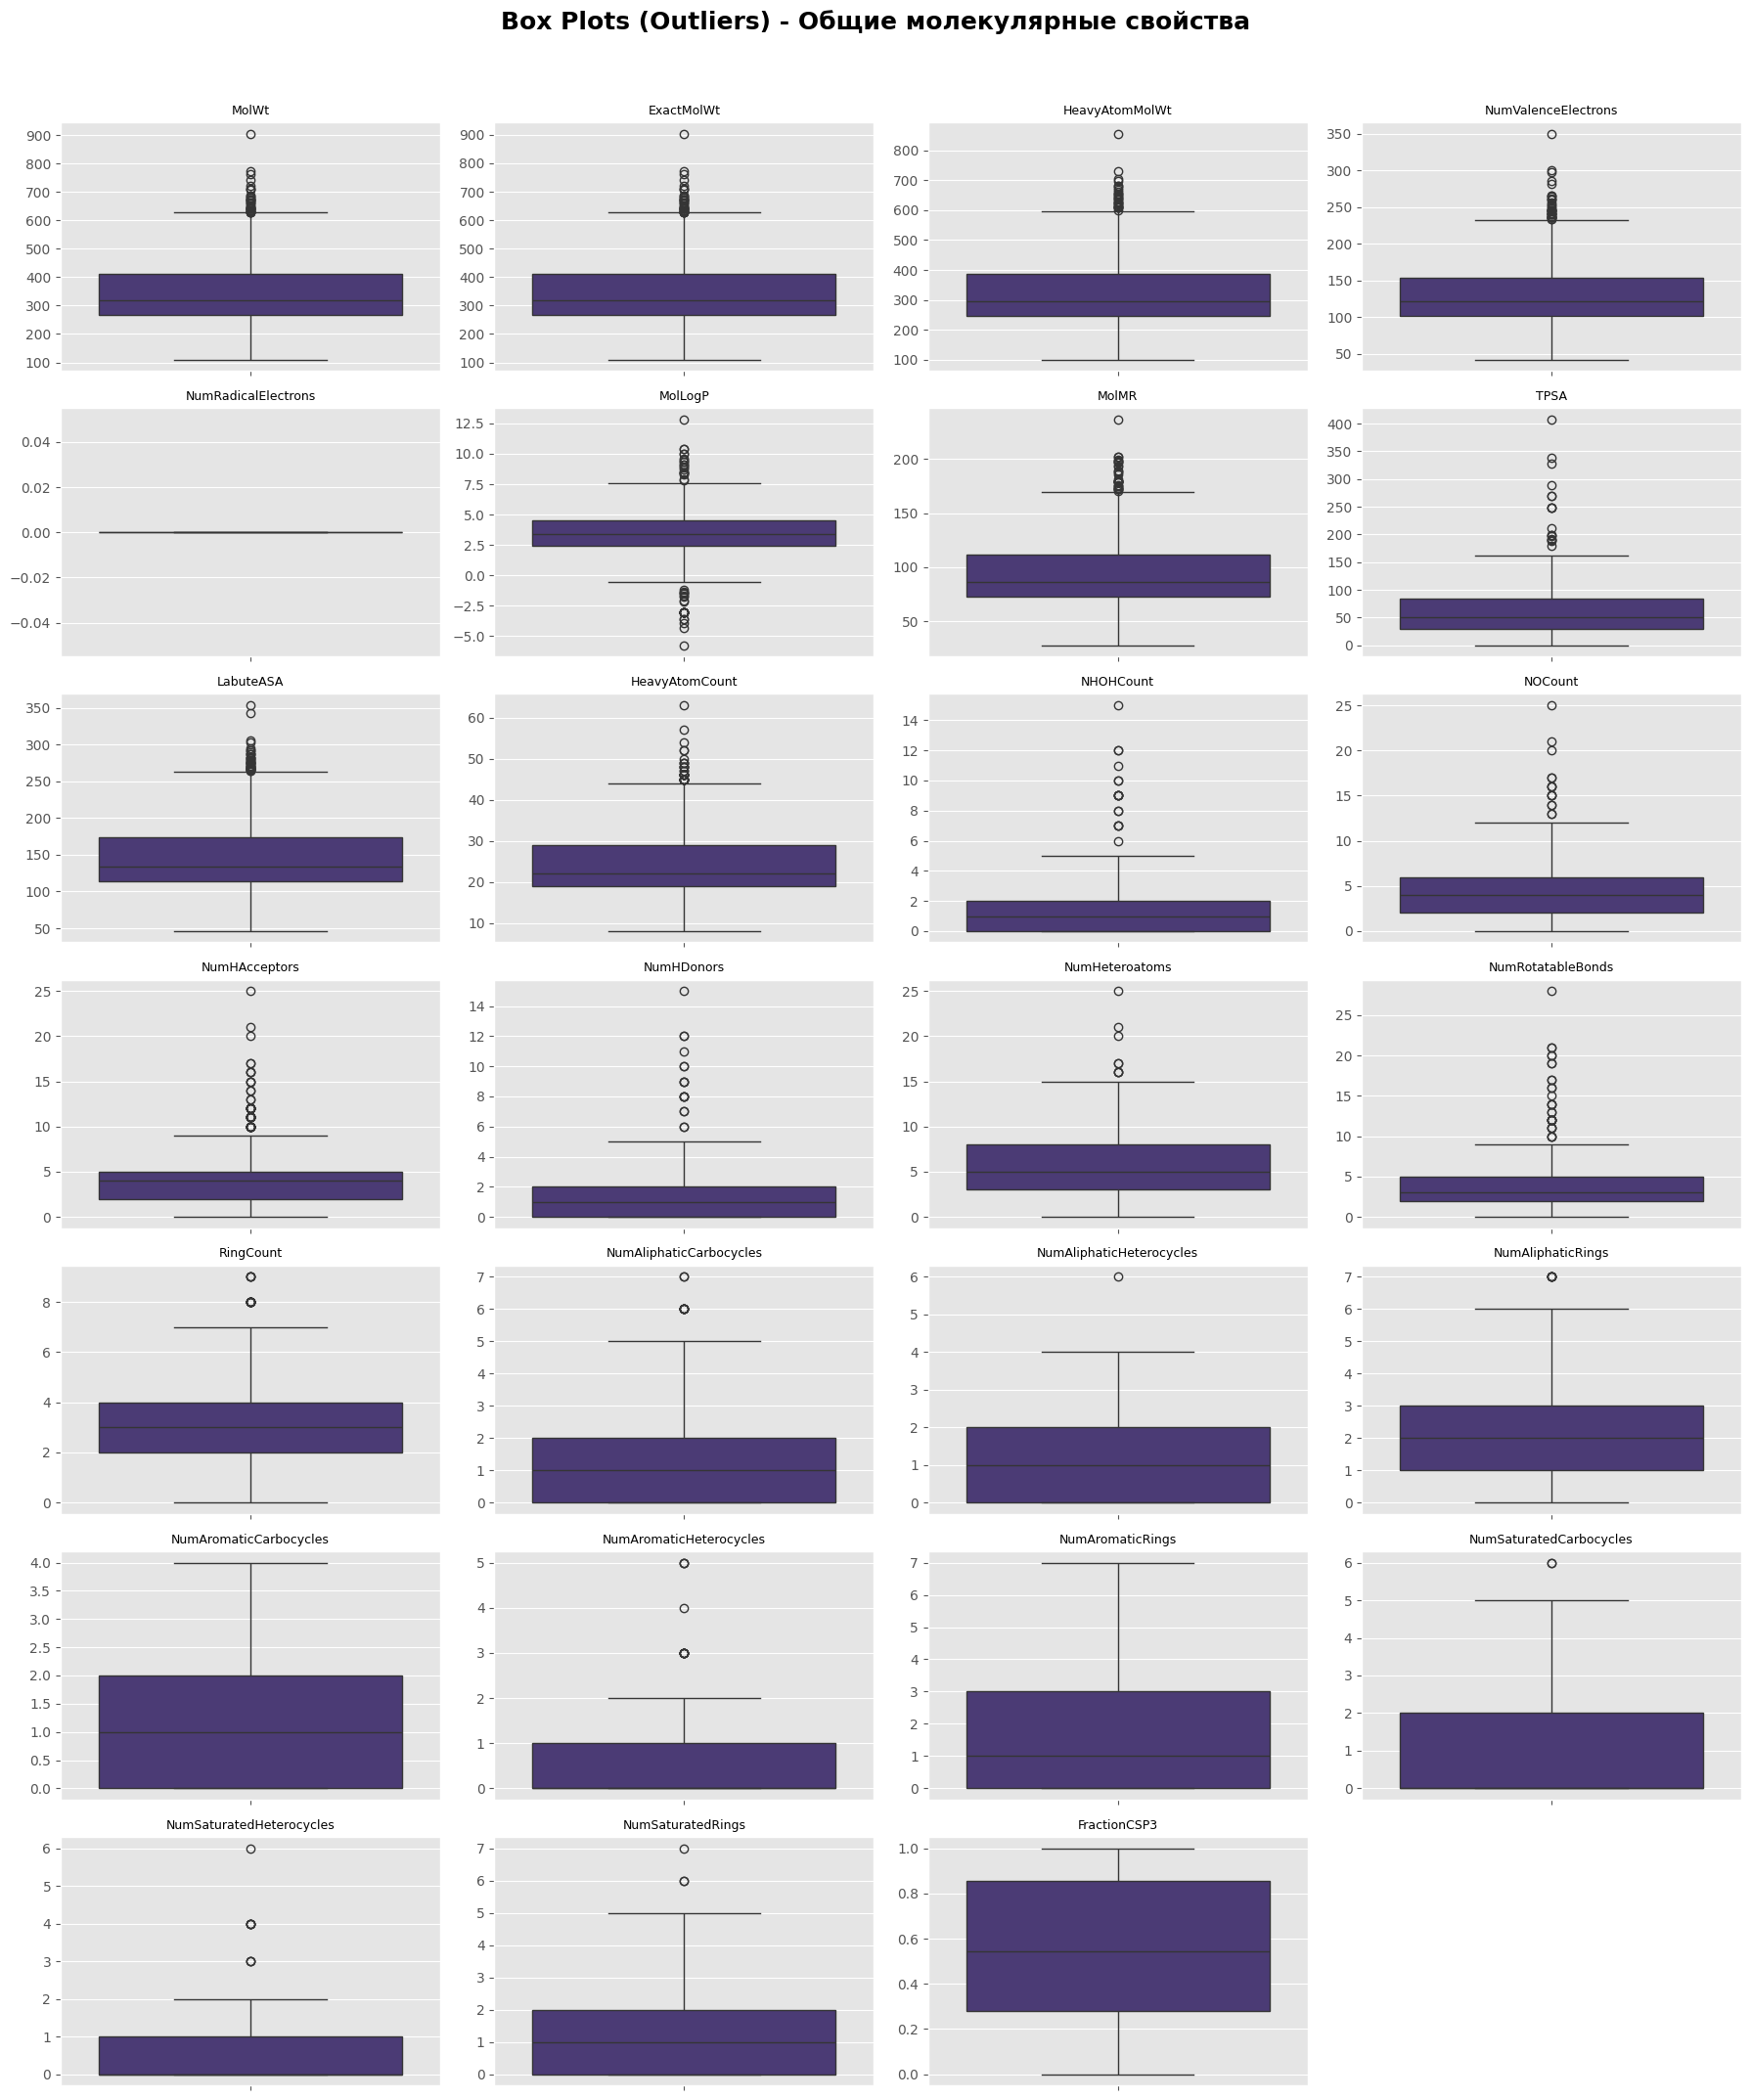

АНАЛИЗ ВЫБРОСОВ (метод IQR)


,feature,outliers_count,outliers_pct
12,NumHAcceptors,73,9.720373
5,MolLogP,49,6.524634
8,LabuteASA,39,5.193076
1,ExactMolWt,37,4.926764
3,NumValenceElectrons,36,4.793609
0,MolWt,36,4.793609
9,HeavyAtomCount,35,4.660453
6,MolMR,31,4.127830
2,HeavyAtomMolWt,29,3.861518
15,NumRotatableBonds,29,3.861518


In [8]:
# ── G1: Анализ распределений и выбросов ──────────────────────────────────
plot_distributions(train, GENERAL_MOLECULAR_PROPERTIES,
                   group_name=GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME)
plot_boxplots(train, GENERAL_MOLECULAR_PROPERTIES,
              group_name=GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME)

print("АНАЛИЗ ВЫБРОСОВ (метод IQR)")
display(analyze_outliers(train, GENERAL_MOLECULAR_PROPERTIES))

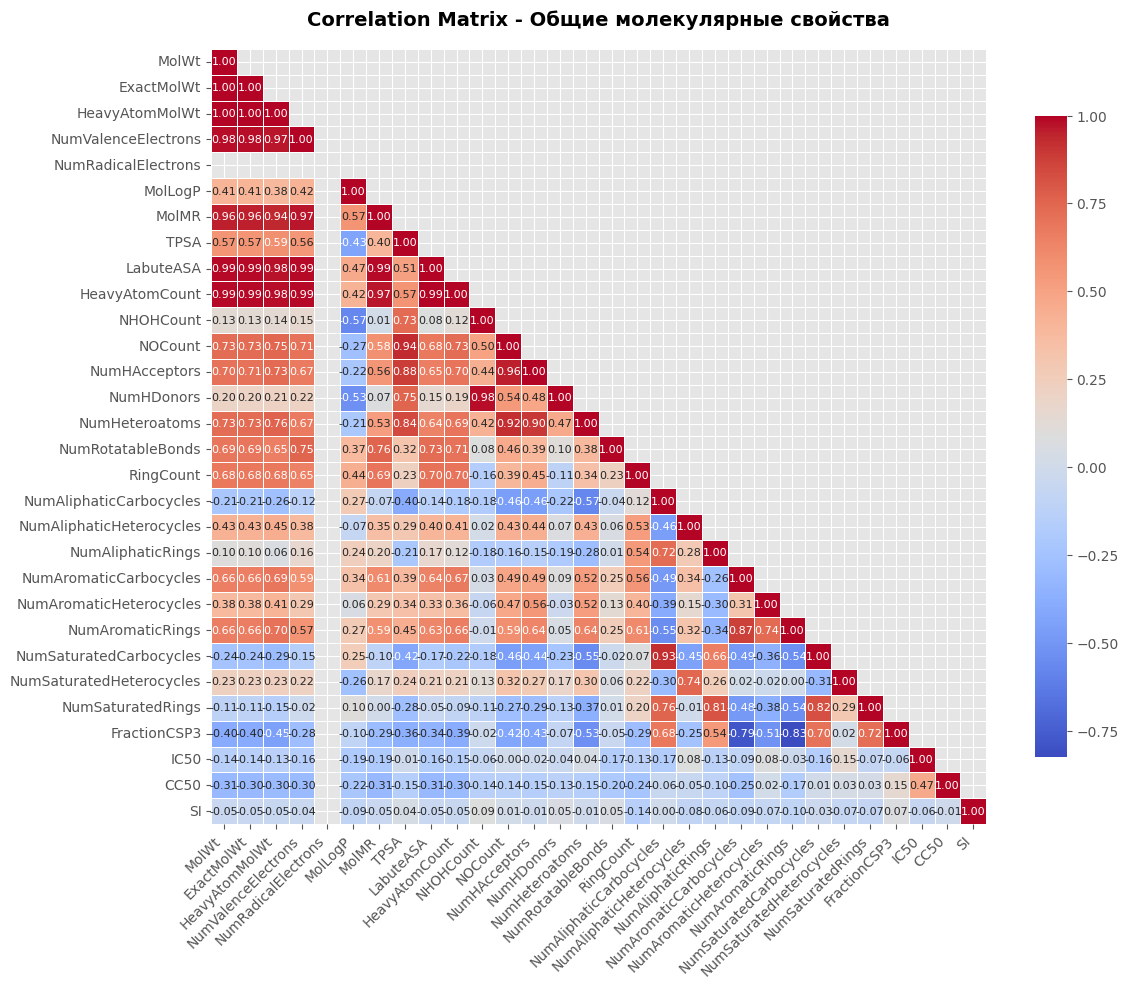

ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.95


,feature1,feature2,correlation
0,MolWt,ExactMolWt,0.999999
1,MolWt,HeavyAtomMolWt,0.996985
6,ExactMolWt,HeavyAtomMolWt,0.996955
19,LabuteASA,HeavyAtomCount,0.994571
16,NumValenceElectrons,HeavyAtomCount,0.990679
15,NumValenceElectrons,LabuteASA,0.990416
10,ExactMolWt,HeavyAtomCount,0.989688
5,MolWt,HeavyAtomCount,0.989531
9,ExactMolWt,LabuteASA,0.988640
4,MolWt,LabuteASA,0.988563


In [9]:
# ── G1: Корреляционный анализ ─────────────────────────────────────────────
corr_matrix = plot_correlation_heatmap(train, GENERAL_MOLECULAR_PROPERTIES, TARGETS,
                                       group_name=GENERAL_MOLECULAR_PROPERTIES_GORUP_NAME)

high_corr_pairs = find_highly_correlated_pairs(train, GENERAL_MOLECULAR_PROPERTIES, threshold=0.95)
print("ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.95")
display(high_corr_pairs)

In [10]:
# ── G1: Аддитивность кольцевых дескрипторов проверяется в G3 (общий цикл)
# Здесь только подтверждаем, что суммарные кольцевые — линейные комбинации компонент
print("Кольцевые дескрипторы (NumAliphaticRings, NumAromaticRings, NumSaturatedRings)")
print("являются точными суммами своих компонент — детально верифицировано в G3.")

Кольцевые дескрипторы (NumAliphaticRings, NumAromaticRings, NumSaturatedRings)
являются точными суммами своих компонент — детально верифицировано в G3.


In [11]:
# ── G1: Дрифт и корреляция с таргетами ───────────────────────────────────
drift_report_g1 = detect_drift(train, test, GENERAL_MOLECULAR_PROPERTIES)
drift_detected_g1 = drift_report_g1[drift_report_g1['drift'] == True]
if len(drift_detected_g1) == 0:
    print("Дрифт распределений между train и test отсутствует.")
else:
    print("Обнаружен дрифт у следующих признаков:")
    display(drift_detected_g1)

print_top_correlations_with_targets(train, GENERAL_MOLECULAR_PROPERTIES, TARGETS)

Обнаружен дрифт у следующих признаков:


,feature,ks_statistic,p_value,drift
3,NumValenceElectrons,0.108676,0.021537,True
8,LabuteASA,0.099393,0.044775,True



Топ-5 признаков с IC50:
  MolMR                                Пирсон=-0.1929 (слабая), Спирмен=-0.1030
  MolLogP                              Пирсон=-0.1897 (слабая), Спирмен=-0.1473
  NumAliphaticCarbocycles              Пирсон=-0.1740 (слабая), Спирмен=-0.2172
  NumRotatableBonds                    Пирсон=-0.1660 (слабая), Спирмен=-0.2120
  LabuteASA                            Пирсон=-0.1650 (слабая), Спирмен=-0.0733

Топ-5 признаков с CC50:
  LabuteASA                            Пирсон=-0.3066 (умеренная), Спирмен=-0.2621
  MolMR                                Пирсон=-0.3066 (умеренная), Спирмен=-0.2663
  MolWt                                Пирсон=-0.3050 (умеренная), Спирмен=-0.2520
  ExactMolWt                           Пирсон=-0.3050 (умеренная), Спирмен=-0.2518
  HeavyAtomCount                       Пирсон=-0.3038 (умеренная), Спирмен=-0.2576

Топ-5 признаков с SI:
  RingCount                            Пирсон=-0.1417 (слабая), Спирмен=-0.1565
  NumAromaticRings              

In [12]:
# ── G1: Удаление избыточных признаков ────────────────────────────────────
# NumRadicalElectrons — константный (std=0)
# ExactMolWt, HeavyAtomMolWt — дублируют MolWt (r > 0.99); оставлен MolMR
# NumValenceElectrons, LabuteASA, HeavyAtomCount — высокая корреляция (r > 0.99)
# NHOHCount, NOCount, NumHAcceptors, NumHDonors — дублируют NumHeteroatoms
# NumAliphaticRings, NumAromaticRings, NumSaturatedRings — точные суммы компонент

GENERAL_MOLECULAR_PROPERTIES_TO_DROP = [
    'MolWt',
    'ExactMolWt',
    'HeavyAtomMolWt',
    'NumValenceElectrons',
    'LabuteASA',
    'HeavyAtomCount',
    'NHOHCount',
    'NOCount',
    'NumHAcceptors',
    'NumHDonors',
    'NumAliphaticRings',
    'NumAromaticRings',
    'NumSaturatedRings',
    'NumRadicalElectrons',
]

train = train.drop(columns=GENERAL_MOLECULAR_PROPERTIES_TO_DROP)
test  = test.drop(columns=GENERAL_MOLECULAR_PROPERTIES_TO_DROP)
GENERAL_MOLECULAR_PROPERTIES = [f for f in GENERAL_MOLECULAR_PROPERTIES
                                 if f not in GENERAL_MOLECULAR_PROPERTIES_TO_DROP]

print(f"Оставшиеся признаки ({len(GENERAL_MOLECULAR_PROPERTIES)}): {GENERAL_MOLECULAR_PROPERTIES}")

Оставшиеся признаки (13): ['MolLogP', 'MolMR', 'TPSA', 'NumHeteroatoms', 'NumRotatableBonds', 'RingCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'FractionCSP3']


### Выводы G1 — Общие молекулярные свойства

**Качество данных:**
| Показатель | Результат |
|------------|-----------|
| Пропуски | Отсутствуют во всех признаках (0%) |
| Выбросы | 3 признака >5% выбросов: `NumHAcceptors` (9.7%), `MolLogP` (6.5%), `LabuteASA` (5.2%) |
| Константные | `NumRadicalElectrons` — удалён |
| Дублирующие | 13 признаков удалены из-за высокой корреляции или линейной зависимости |

**Итог:** удалено 14 из 27 признаков, **осталось 13**.

## Группа 2 — Электронные и зарядовые характеристики

18 признаков: 4 зарядовых + 14 PEOE_VSA (распределение электронной плотности по поверхности).

In [13]:
# ── G2: Определение признаков ─────────────────────────────────────────────

ELECTRONIC_GROUP_NAME = 'Электронные и зарядовые характеристики'
ELECTRONIC_FEATURES = [
    'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge',
    'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5',
    'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'PEOE_VSA10',
    'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14'
]

display_columns_info(train, ELECTRONIC_FEATURES)

,column,dtype,missing,missing_pct,unique,min,max,mean,std
0,MaxPartialCharge,float64,2,0.266312,570,-0.016706,0.572596,0.236088,0.129798
1,MinPartialCharge,float64,2,0.266312,529,-0.744036,-0.085007,-0.407257,0.077049
2,MaxAbsPartialCharge,float64,2,0.266312,531,0.085007,0.744036,0.415155,0.073365
3,MinAbsPartialCharge,float64,2,0.266312,571,0.002020,0.507387,0.228304,0.120489
4,PEOE_VSA1,float64,0,0.000000,126,0.000000,118.909965,12.748657,11.863463
5,PEOE_VSA2,float64,0,0.000000,57,0.000000,34.192377,6.096116,5.993614
6,PEOE_VSA3,float64,0,0.000000,41,0.000000,43.457663,3.042701,5.114222
7,PEOE_VSA4,float64,0,0.000000,30,0.000000,44.612417,2.998144,6.723970
8,PEOE_VSA5,float64,0,0.000000,13,0.000000,23.523770,1.670536,4.290294
9,PEOE_VSA6,float64,0,0.000000,200,0.000000,128.895212,27.004518,21.211464


In [14]:
# ── G2: Обработка пропусков ───────────────────────────────────────────────
# В 4 зарядовых признаках по 2 пропуска (0.27%) — заполняем медианой train
charge_cols_with_missing = ['MaxPartialCharge', 'MinPartialCharge',
                             'MaxAbsPartialCharge', 'MinAbsPartialCharge']
for col in charge_cols_with_missing:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)
print("Пропуски заполнены медианами.")

# Константные / почти константные
constant_g2 = find_constant_features(train, ELECTRONIC_FEATURES)
low_var_g2  = find_low_variance_features(train, ELECTRONIC_FEATURES, threshold=0.01)
print(f"Константные: {constant_g2}")
print(f"Почти константные: {low_var_g2}")

Пропуски заполнены медианами.
Константные: []
Почти константные: ['MinPartialCharge', 'MaxAbsPartialCharge']


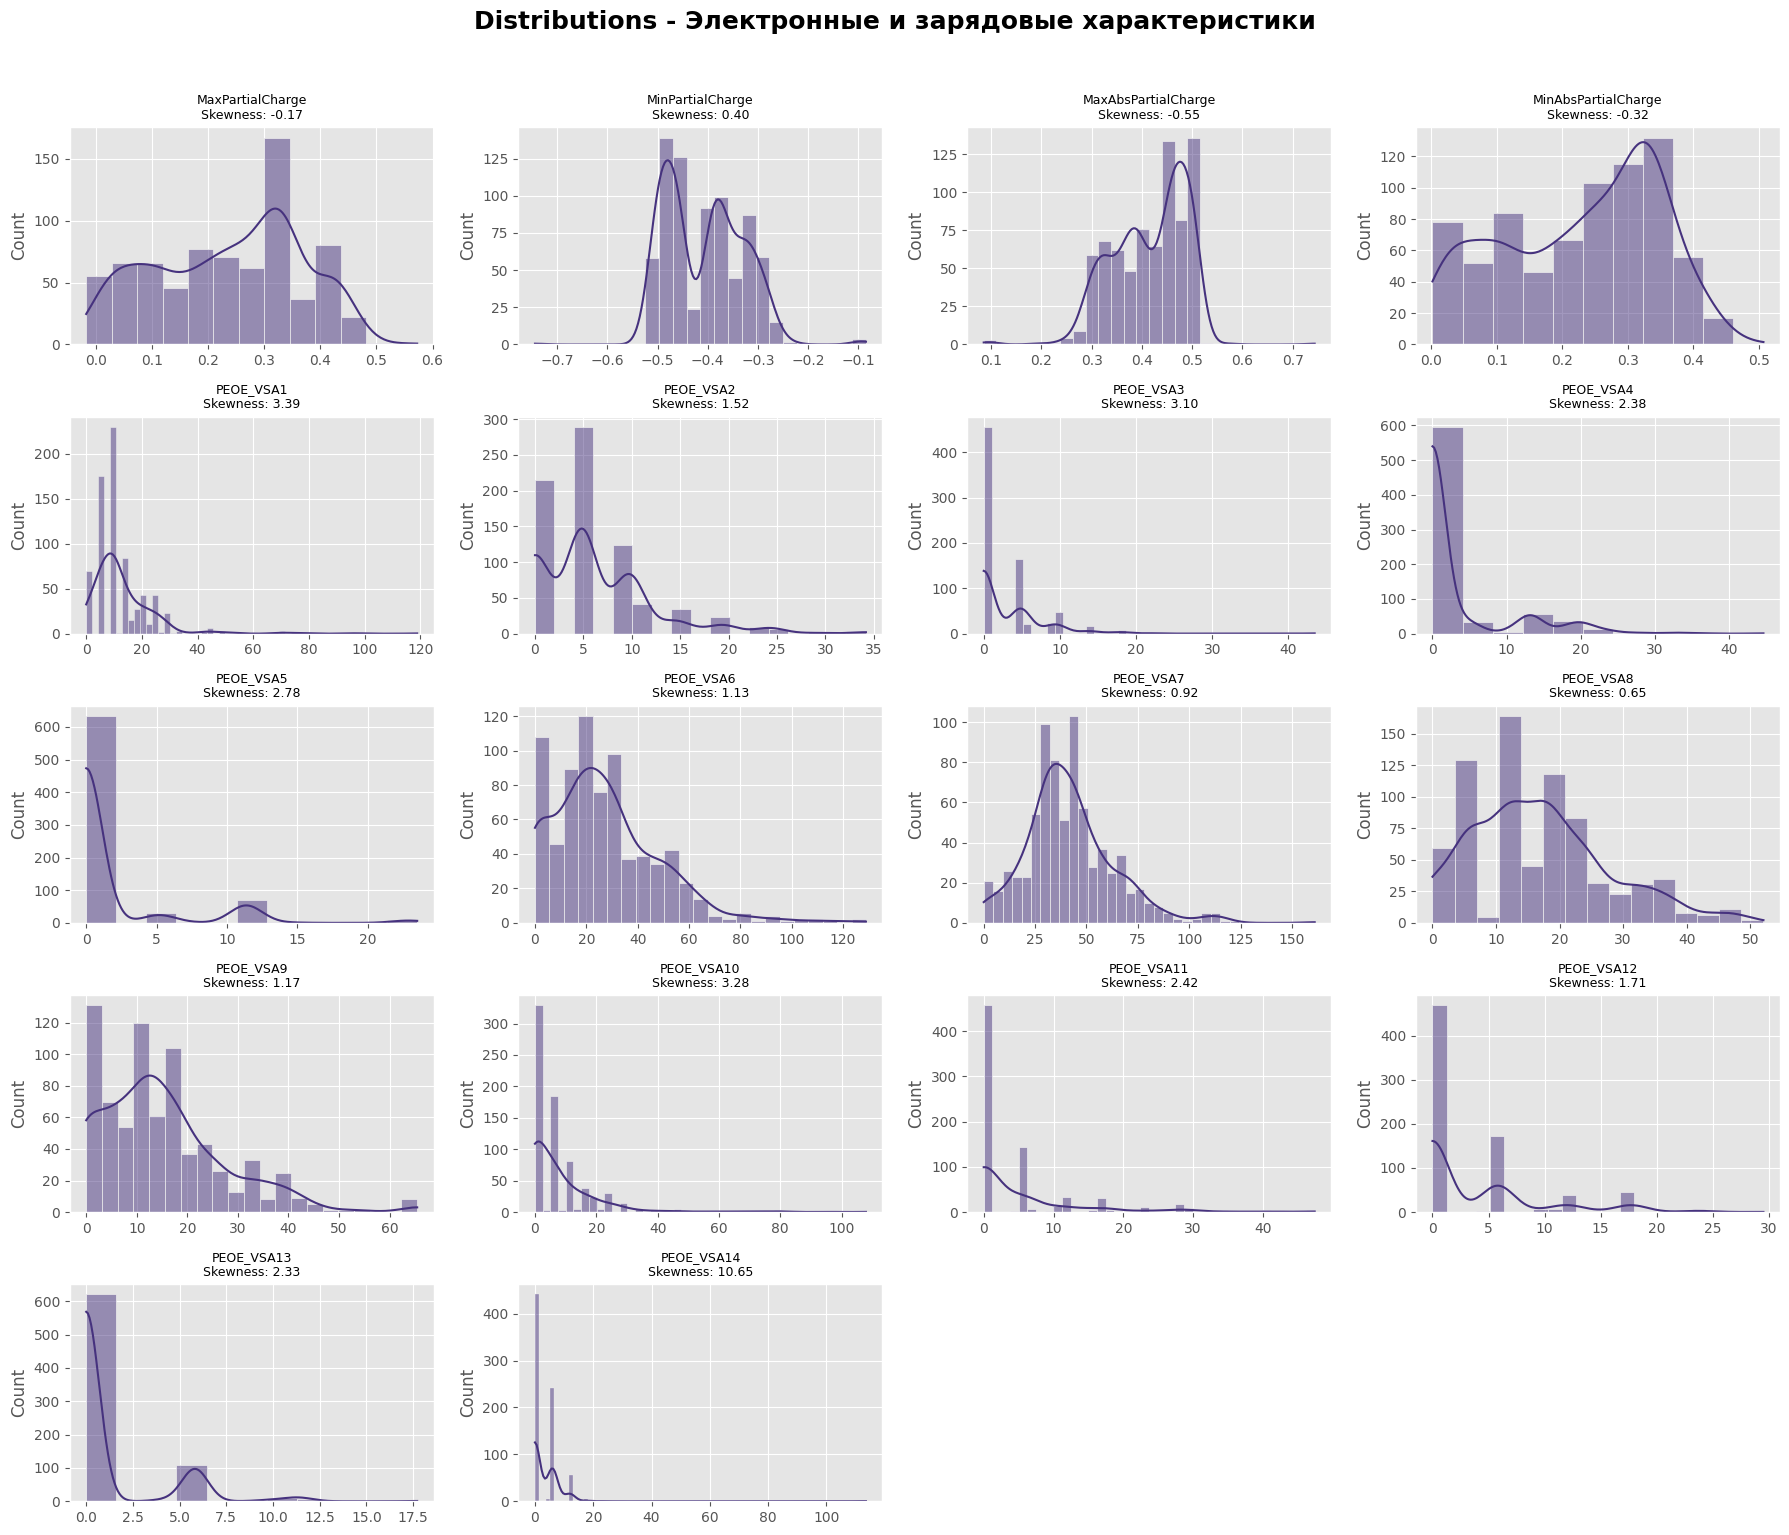

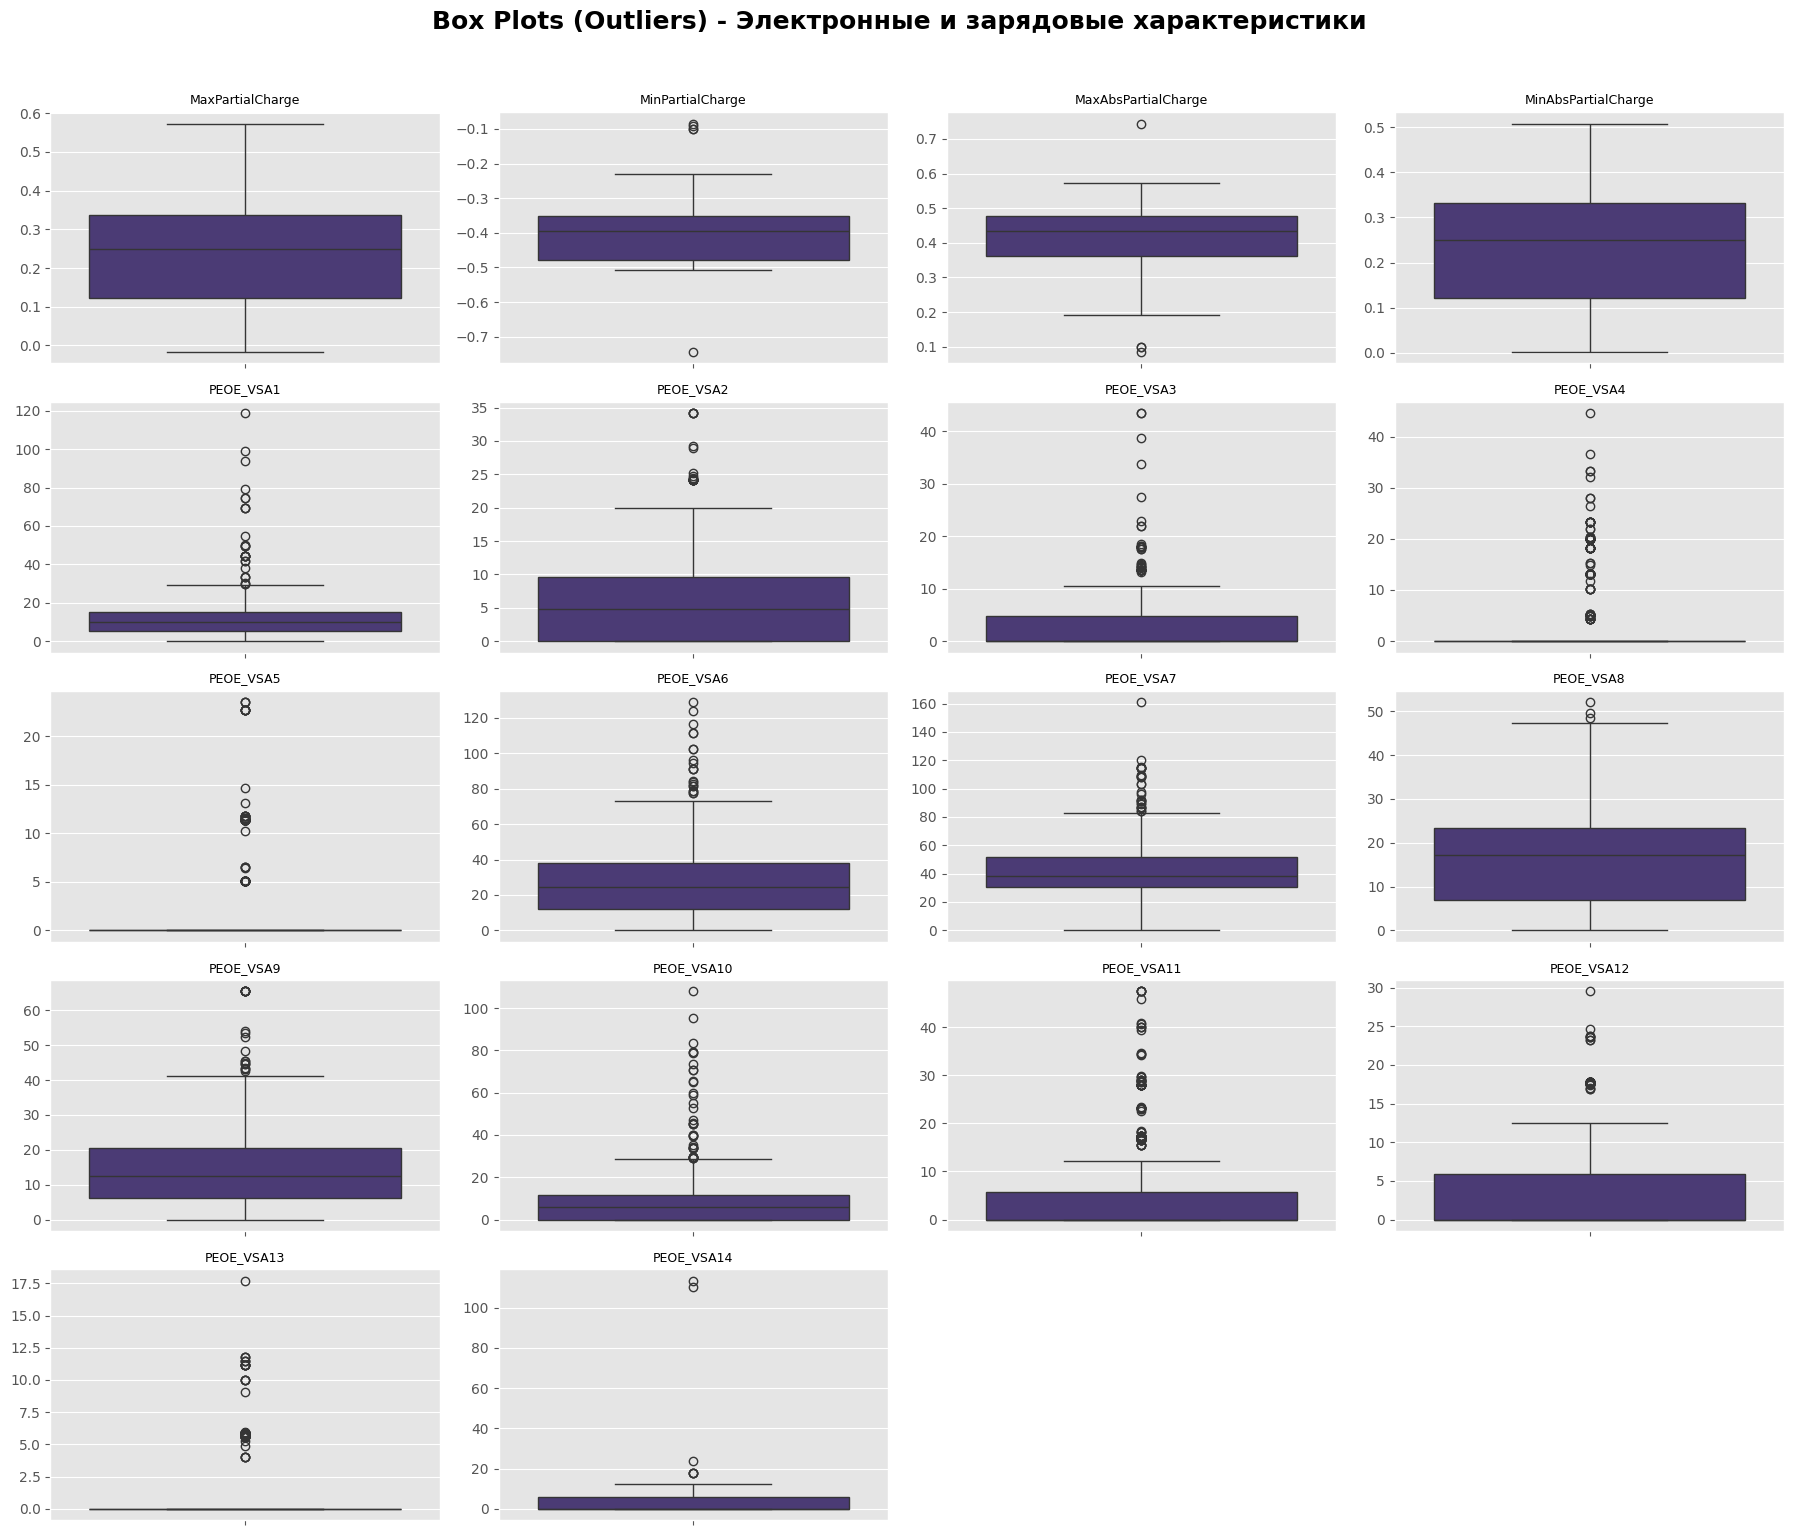

АНАЛИЗ ВЫБРОСОВ (метод IQR)


,feature,outliers_count,outliers_pct
7,PEOE_VSA4,155,20.639148
16,PEOE_VSA13,131,17.443409
8,PEOE_VSA5,118,15.712383
14,PEOE_VSA11,92,12.250333
15,PEOE_VSA12,55,7.323569
13,PEOE_VSA10,38,5.059920
6,PEOE_VSA3,38,5.059920
4,PEOE_VSA1,29,3.861518
10,PEOE_VSA7,29,3.861518
5,PEOE_VSA2,22,2.929427


In [15]:
# ── G2: Анализ распределений и выбросов ──────────────────────────────────
plot_distributions(train, ELECTRONIC_FEATURES, group_name=ELECTRONIC_GROUP_NAME)
plot_boxplots(train, ELECTRONIC_FEATURES, group_name=ELECTRONIC_GROUP_NAME)

print("АНАЛИЗ ВЫБРОСОВ (метод IQR)")
display(analyze_outliers(train, ELECTRONIC_FEATURES))

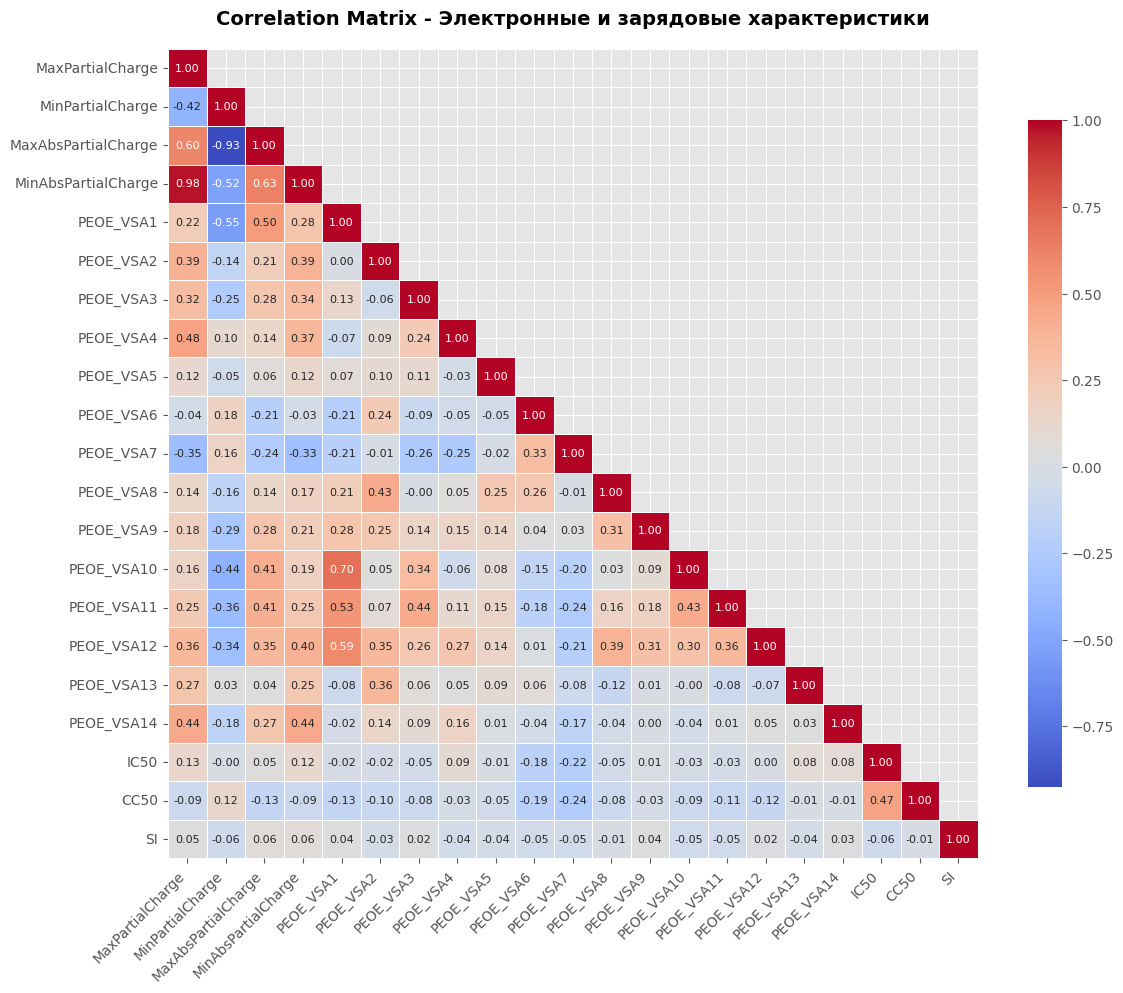

ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.95


,feature1,feature2,correlation
0,MaxPartialCharge,MinAbsPartialCharge,0.975233


In [16]:
# ── G2: Корреляционный анализ ─────────────────────────────────────────────
corr_matrix_g2 = plot_correlation_heatmap(train, ELECTRONIC_FEATURES, TARGETS,
                                          group_name=ELECTRONIC_GROUP_NAME)

high_corr_g2 = find_highly_correlated_pairs(train, ELECTRONIC_FEATURES, threshold=0.95)
print("ПАРЫ ПРИЗНАКОВ С КОРРЕЛЯЦИЕЙ > 0.95")
display(high_corr_g2)

In [17]:
# ── G2: Дрифт и корреляция с таргетами ───────────────────────────────────
drift_report_g2 = detect_drift(train, test, ELECTRONIC_FEATURES)
drift_detected_g2 = drift_report_g2[drift_report_g2['drift'] == True]
if len(drift_detected_g2) == 0:
    print("Дрифт распределений между train и test отсутствует.")
else:
    print("Обнаружен дрифт у следующих признаков:")
    display(drift_detected_g2)

print_top_correlations_with_targets(train, ELECTRONIC_FEATURES, TARGETS)

Дрифт распределений между train и test отсутствует.

Топ-5 признаков с IC50:
  PEOE_VSA7                            Пирсон=-0.2175 (слабая), Спирмен=-0.1824
  PEOE_VSA6                            Пирсон=-0.1820 (слабая), Спирмен=-0.1655
  MaxPartialCharge                     Пирсон=+0.1332 (слабая), Спирмен=+0.0793
  MinAbsPartialCharge                  Пирсон=+0.1178 (слабая), Спирмен=+0.0746
  PEOE_VSA4                            Пирсон=+0.0911 (очень слабая), Спирмен=+0.0948

Топ-5 признаков с CC50:
  PEOE_VSA7                            Пирсон=-0.2385 (слабая), Спирмен=-0.2460
  PEOE_VSA6                            Пирсон=-0.1937 (слабая), Спирмен=-0.1774
  PEOE_VSA1                            Пирсон=-0.1350 (слабая), Спирмен=-0.1176
  MaxAbsPartialCharge                  Пирсон=-0.1295 (слабая), Спирмен=-0.0999
  MinPartialCharge                     Пирсон=+0.1211 (слабая), Спирмен=+0.0884

Топ-5 признаков с SI:
  MinPartialCharge                     Пирсон=-0.0641 (очень слабая),

In [18]:
# ── G2: Удаление избыточных признаков ────────────────────────────────────
# MinAbsPartialCharge дублирует MaxPartialCharge (r = 0.975)
# MinPartialCharge и MaxAbsPartialCharge — почти константные, зеркальная корреляция (r ≈ −0.93)

ELECTRONIC_FEATURES_TO_DROP = ['MinAbsPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge']

train = train.drop(columns=ELECTRONIC_FEATURES_TO_DROP)
test  = test.drop(columns=ELECTRONIC_FEATURES_TO_DROP)
ELECTRONIC_FEATURES = [f for f in ELECTRONIC_FEATURES if f not in ELECTRONIC_FEATURES_TO_DROP]

print(f"Оставшиеся признаки ({len(ELECTRONIC_FEATURES)}): {ELECTRONIC_FEATURES}")

Оставшиеся признаки (15): ['MaxPartialCharge', 'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14']


In [19]:
# ── G2: KMeans-кластеризация по PEOE_VSA ─────────────────────────────────
peoe_features = [f for f in ELECTRONIC_FEATURES if f.startswith('PEOE')]

scaler_for_cluster = StandardScaler()
train_peoe_scaled = scaler_for_cluster.fit_transform(train[peoe_features])
test_peoe_scaled  = scaler_for_cluster.transform(test[peoe_features])

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init='auto')
train['peoe_cluster'] = kmeans.fit_predict(train_peoe_scaled)
test['peoe_cluster']  = kmeans.predict(test_peoe_scaled)

print("Распределение по кластерам в train:")
print(train['peoe_cluster'].value_counts())

print("\nСредние IC50, CC50, SI по кластерам:")
display(train.groupby('peoe_cluster')[TARGETS].mean())

Распределение по кластерам в train:
peoe_cluster
1    453
2    186
0    112
Name: count, dtype: int64

Средние IC50, CC50, SI по кластерам:


,IC50,CC50,SI
peoe_cluster,,,
0,126.016663,378.406018,11.739799
1,217.271128,652.932702,45.817929
2,220.832650,513.371032,241.310532


In [20]:
# ── G2: ANOVA — проверка значимости кластеров ────────────────────────────
print("ANOVA: проверка различий средних значений таргетов по кластерам")
for target in TARGETS:
    groups = [train[train['peoe_cluster'] == i][target] for i in range(3)]
    f_stat, p_val = f_oneway(*groups)
    print(f"{target}: F = {f_stat:.2f}, p-value = {p_val:.4f} ({interpret_statistical_significance(p_val)})")

# ── G2: One-Hot Encoding кластеров ────────────────────────────────────────
encoder = OneHotEncoder(sparse_output=False)

cluster_train = encoder.fit_transform(train[['peoe_cluster']])
cluster_test  = encoder.transform(test[['peoe_cluster']])
cluster_cols  = [f'cluster_{i}' for i in range(cluster_train.shape[1])]

train_cluster_df = pd.DataFrame(cluster_train, columns=cluster_cols, index=train.index)
test_cluster_df  = pd.DataFrame(cluster_test,  columns=cluster_cols, index=test.index)

train = pd.concat([train, train_cluster_df], axis=1)
test  = pd.concat([test,  test_cluster_df],  axis=1)

# Удаляем вспомогательный столбец
train = train.drop(columns=['peoe_cluster'])
test  = test.drop(columns=['peoe_cluster'])

ELECTRONIC_FEATURES = ELECTRONIC_FEATURES + cluster_cols
print(f"Добавлены дамми-признаки: {cluster_cols}")
print(f"Итого признаков G2: {len(ELECTRONIC_FEATURES)}")

ANOVA: проверка различий средних значений таргетов по кластерам
IC50: F = 2.98, p-value = 0.0514 (не значимо)
CC50: F = 9.67, p-value = 0.0001 (высокозначимо)
SI: F = 4.73, p-value = 0.0091 (очень значимо)
Добавлены дамми-признаки: ['cluster_0', 'cluster_1', 'cluster_2']
Итого признаков G2: 18


### Выводы G2 — Электронные и зарядовые характеристики

| Показатель | Результат |
|------------|-----------|
| Пропуски | В 4 зарядовых признаках по 2 NaN → заполнены медианой train |
| Удалены | `MinAbsPartialCharge`, `MinPartialCharge`, `MaxAbsPartialCharge` (дубликаты/почти константные) |
| Выбросы | `PEOE_VSA4` (155), `PEOE_VSA13` (131), `PEOE_VSA5` (118) — робастное масштабирование |
| Дрифт | Отсутствует |
| KMeans (k=3) | ANOVA: CC50 p≈0.0001, SI p≈0.009 — кластеры значимо разделяют по цитотоксичности и селективности |

**Итог:** удалено 3, добавлено 3 кластерных дамми, **итого 18 признаков**.

## Группа 3 — Топологические и структурные дескрипторы

32 признака: Chi-индексы (χ), Kappa-индексы (κ), BalabanJ, BertzCT, HallKierAlpha, Ipc/AvgIpc, FractionCSP3 и кольцевые дескрипторы.

In [21]:
# ── G3: Определение признаков ─────────────────────────────────────────────

TOPOLOGICAL_GROUP_NAME = 'Топологические и структурные дескрипторы'

TOPOLOGICAL_FEATURES = [
    # Chi-индексы связности (Randic): базовый, нормализованный (n), валентный (v)
    'Chi0', 'Chi0n', 'Chi0v',
    'Chi1', 'Chi1n', 'Chi1v',
    'Chi2n', 'Chi2v',
    'Chi3n', 'Chi3v',
    'Chi4n', 'Chi4v',
    # Kappa-индексы формы (Kier)
    'Kappa1', 'Kappa2', 'Kappa3',
    # Прочие топологические
    'BalabanJ', 'BertzCT', 'HallKierAlpha', 'Ipc', 'AvgIpc',
    # Структурные / кольцевые
    'FractionCSP3', 'RingCount',
    'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings',
    'NumAromaticCarbocycles',  'NumAromaticHeterocycles',  'NumAromaticRings',
    'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings',
    'NumRotatableBonds',
]

# Оставляем только те, что ещё есть в датафрейме (часть удалена в G1)
TOPOLOGICAL_FEATURES = [f for f in TOPOLOGICAL_FEATURES if f in train.columns]
print(f"Признаков в группе (с учётом удалённых в G1): {len(TOPOLOGICAL_FEATURES)}")

display_columns_info(train, TOPOLOGICAL_FEATURES)

Признаков в группе (с учётом удалённых в G1): 29


,column,dtype,missing,missing_pct,unique,min,max,mean,std
0,Chi0,float64,0,0.0,403,5.560478e+00,4.576397e+01,1.786527e+01,6.400506e+00
1,Chi0n,float64,0,0.0,557,4.112077e+00,3.598698e+01,1.468173e+01,5.196354e+00
2,Chi0v,float64,0,0.0,587,4.112077e+00,3.598698e+01,1.501630e+01,5.297802e+00
3,Chi1,float64,0,0.0,503,3.860173e+00,2.980075e+01,1.188158e+01,4.501564e+00
4,Chi1n,float64,0,0.0,588,2.128962e+00,2.221343e+01,8.745933e+00,3.132727e+00
5,Chi1v,float64,0,0.0,613,2.128962e+00,2.221343e+01,9.046804e+00,3.233148e+00
6,Chi2n,float64,0,0.0,601,1.301253e+00,2.018094e+01,7.386271e+00,2.717798e+00
7,Chi2v,float64,0,0.0,627,1.301253e+00,2.018094e+01,7.731049e+00,2.810973e+00
8,Chi3n,float64,0,0.0,604,7.499893e-01,1.647664e+01,5.673311e+00,2.425412e+00
9,Chi3v,float64,0,0.0,630,7.499893e-01,1.647664e+01,5.964689e+00,2.492845e+00


In [22]:
# ── G3: Анализ пропусков ──────────────────────────────────────────────────
missing_pct = (train[TOPOLOGICAL_FEATURES].isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_df  = missing_pct[missing_pct > 0]
if len(missing_df) == 0:
    print("✓ Пропуски в группе отсутствуют.")
else:
    print("Признаки с пропусками:")
    print(missing_df)

✓ Пропуски в группе отсутствуют.


In [24]:
# G3: Быстрый поиск скошенных признаков
skew_series = train[TOPOLOGICAL_FEATURES].skew()
high_skew = skew_series[abs(skew_series) > 1].index.tolist()
print(f"Признаков с |skew| > 1: {len(high_skew)}")
print(high_skew)

# Рисуем только кандидатов — и с оптимизированной функцией
# ОЗУ не хватает plot_distributions(train, high_skew, group_name=TOPOLOGICAL_GROUP_NAME)

Признаков с |skew| > 1: 21
['Chi0n', 'Chi0v', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'Kappa2', 'Kappa3', 'BertzCT', 'Ipc', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAromaticHeterocycles', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumRotatableBonds']


In [23]:
# Тоже не помогло - не ускорило отрисовку (у меня не хватает ресурсов видеокарты)
# def plot_distributions_fast(df, features, group_name, max_cols=4):
#     n = len(features)
#     rows = (n + max_cols - 1) // max_cols
#     fig, axes = plt.subplots(rows, max_cols, figsize=(4*max_cols, 3*rows))
#     axes = axes.flatten() if n > 1 else [axes]
#     for i, f in enumerate(features):
#         if i >= len(axes):
#             break
#         # быстрая гистограмма
#         df[f].dropna().hist(bins=50, ax=axes[i], alpha=0.7, edgecolor='black')
#         axes[i].set_title(f, fontsize=8)
#     for j in range(i+1, len(axes)):
#         axes[j].set_visible(False)
#     plt.suptitle(f'Распределения: {group_name}')
#     plt.tight_layout()
#     plt.show()

In [ ]:
# Пропускаю, т.к. Очень долго выполняется (признаков слишком много - длительная отрисовка)
# # ── G3: Анализ распределений ─────────────────────────────────────────────
# plot_distributions(train, TOPOLOGICAL_FEATURES, group_name=TOPOLOGICAL_GROUP_NAME)

# # Признаки с |skew| > 1 — кандидаты на log1p
# high_skew = [f for f in TOPOLOGICAL_FEATURES if abs(train[f].skew()) > 1]
# print(f"Признаков с |skew| > 1: {len(high_skew)}")
# print(high_skew)

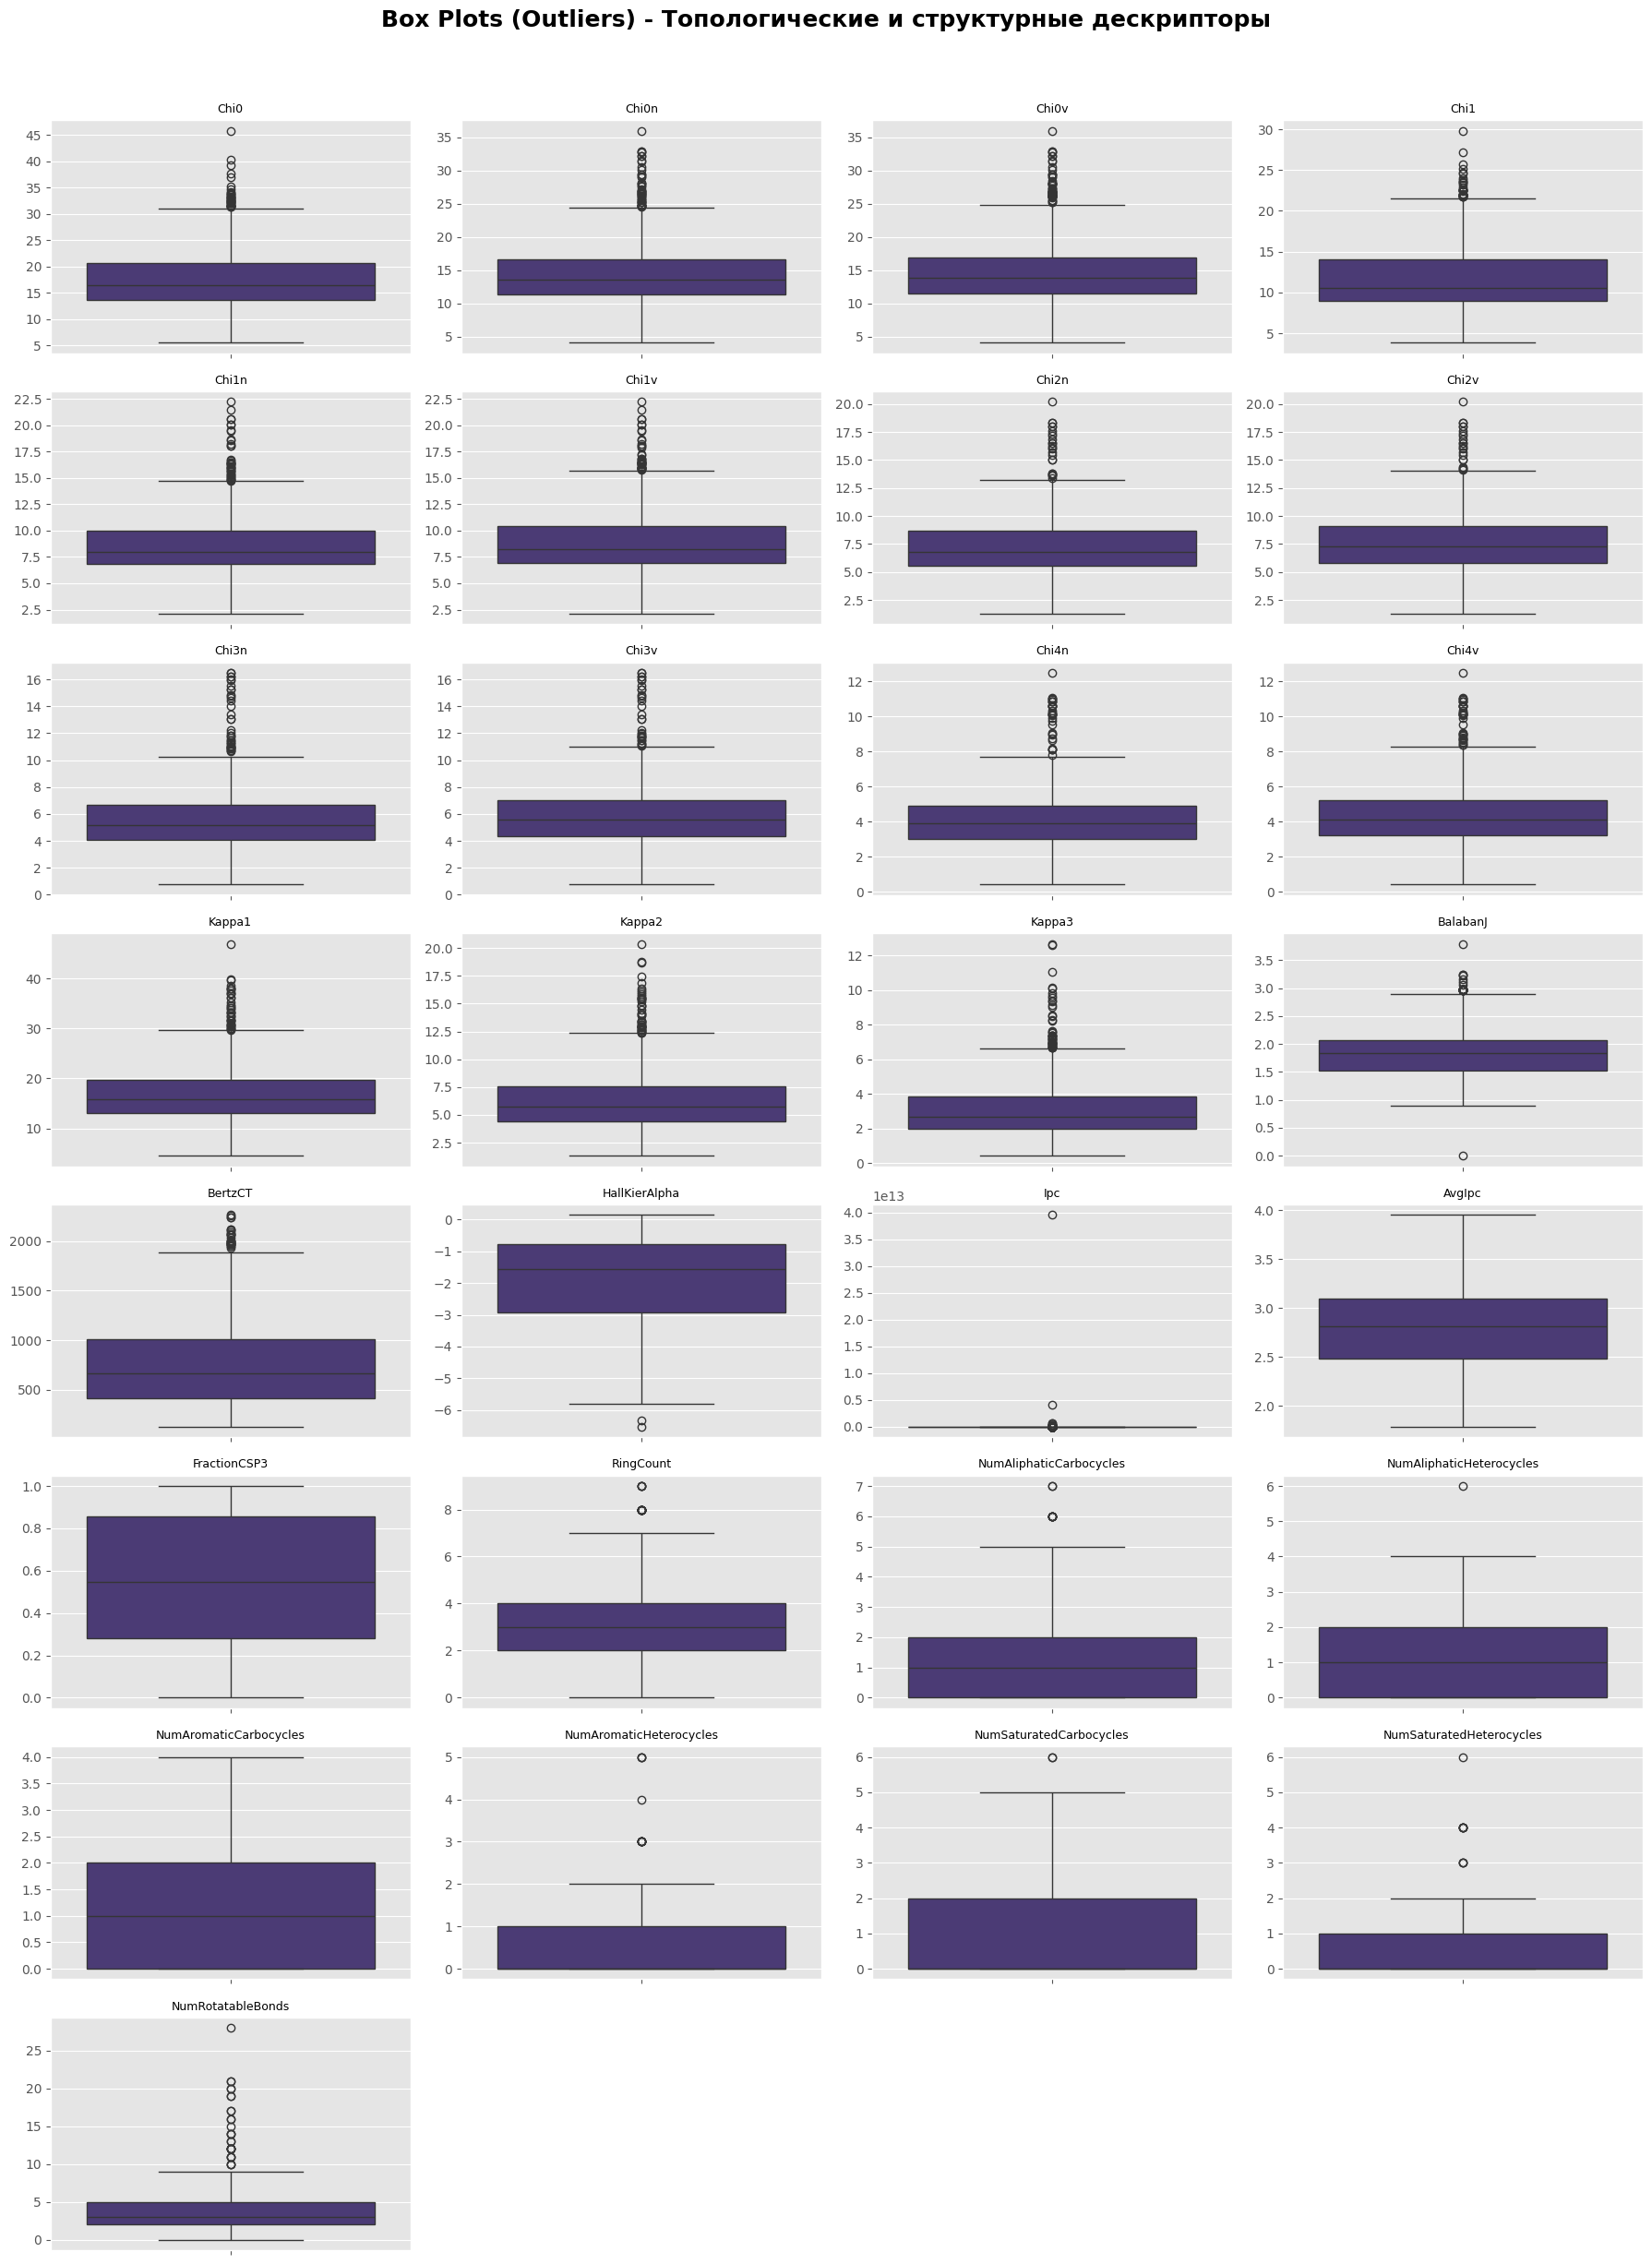

Детальная таблица выбросов (IQR):


,feature,outliers_count,outliers_pct
18,Ipc,154,20.505992
2,Chi0v,53,7.057257
1,Chi0n,48,6.391478
13,Kappa2,46,6.125166
14,Kappa3,45,5.992011
5,Chi1v,40,5.326232
4,Chi1n,39,5.193076
12,Kappa1,38,5.059920
11,Chi4v,37,4.926764
8,Chi3n,37,4.926764


In [27]:
# ── G3: Выбросы ───────────────────────────────────────────────────────────
plot_boxplots(train, TOPOLOGICAL_FEATURES, group_name=TOPOLOGICAL_GROUP_NAME)
print("Детальная таблица выбросов (IQR):")
display(analyze_outliers(train, TOPOLOGICAL_FEATURES))

In [28]:
# ── G3: Проверка аддитивности кольцевых дескрипторов ─────────────────────
checks = [
    ('NumAliphaticRings', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles'),
    ('NumAromaticRings',  'NumAromaticCarbocycles',  'NumAromaticHeterocycles'),
    ('NumSaturatedRings', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles'),
]
for total, comp1, comp2 in checks:
    if total in train.columns:
        is_sum = (train[total] == train[comp1] + train[comp2]).all()
        print(f"{total} == {comp1} + {comp2}: {is_sum}")

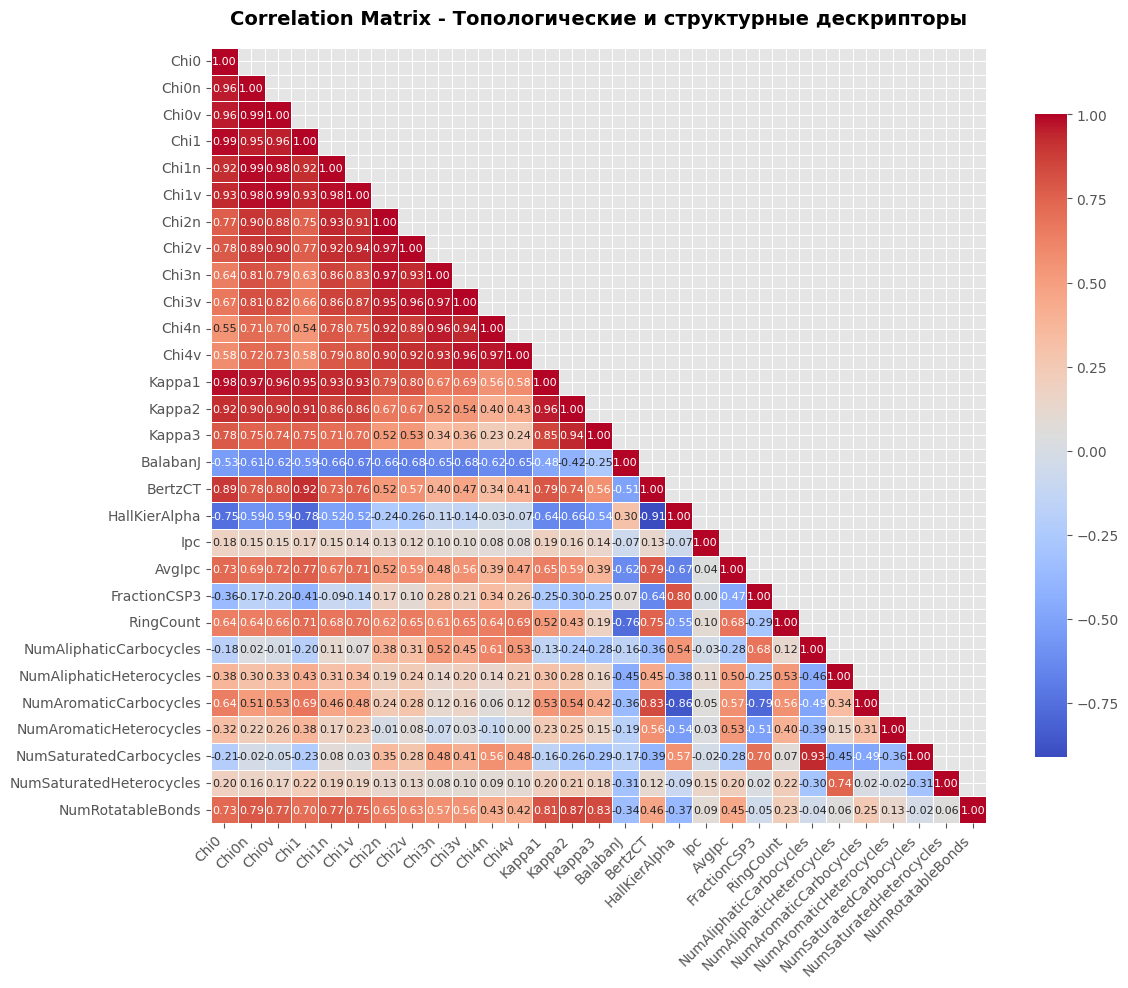

Все пары с |r| > 0.95 — потенциальные дубликаты:


,feature1,feature2,correlation
4,Chi0n,Chi0v,0.992707
2,Chi0,Chi1,0.990843
5,Chi0n,Chi1n,0.988980
10,Chi0v,Chi1v,0.988166
13,Chi1n,Chi1v,0.983764
9,Chi0v,Chi1n,0.979888
3,Chi0,Kappa1,0.979805
6,Chi0n,Chi1v,0.977691
17,Chi3n,Chi3v,0.972204
14,Chi2n,Chi2v,0.970037



Итого пар: 22


In [29]:
# ── G3: Корреляционный анализ ─────────────────────────────────────────────
corr_inner_g3 = plot_correlation_heatmap(train, TOPOLOGICAL_FEATURES,
                                         group_name=TOPOLOGICAL_GROUP_NAME)

print("Все пары с |r| > 0.95 — потенциальные дубликаты:")
high_corr_g3 = find_highly_correlated_pairs(train, TOPOLOGICAL_FEATURES, threshold=0.95)
display(high_corr_g3)
print(f"\nИтого пар: {len(high_corr_g3)}")

In [30]:
# ── G3: Удаление мультиколлинеарных признаков ────────────────────────────
# Chi-индексы образуют «лестницу» корреляций — оставляем только валентные (v):
#   Chi0v, Chi2v, Chi4v (каждый второй уровень)
# Chi1v дублирует Chi0v (r=0.988); Chi3v — «мост» между Chi2v и Chi4v
# Kappa1 ≈ Chi0v (r=0.963); Kappa2 ≈ Kappa1 (r=0.959); Kappa3 — уникален
# NumAliphaticRings / NumAromaticRings / NumSaturatedRings — точные суммы (уже удалены G1)

TOPOLOGICAL_FEATURES_TO_DROP = [
    # Суммарные кольцевые (если ещё не удалены в G1)
    'NumAliphaticRings',
    'NumAromaticRings',
    'NumSaturatedRings',
    # Chi-индексы: оставляем только валентный вариант
    'Chi0',  'Chi0n',
    'Chi1',  'Chi1n',
    'Chi1v',
    'Chi2n',
    'Chi3n',
    'Chi3v',
    'Chi4n',
    # Kappa
    'Kappa1',
    'Kappa2',
]

train = train.drop(columns=TOPOLOGICAL_FEATURES_TO_DROP, errors='ignore')
test  = test.drop(columns=TOPOLOGICAL_FEATURES_TO_DROP, errors='ignore')
TOPOLOGICAL_FEATURES = [f for f in TOPOLOGICAL_FEATURES if f not in TOPOLOGICAL_FEATURES_TO_DROP]

print(f"Удалено признаков: {len(TOPOLOGICAL_FEATURES_TO_DROP)}")
print(f"Осталось признаков: {len(TOPOLOGICAL_FEATURES)}")
print(f"\nИтоговый набор:")
for f in TOPOLOGICAL_FEATURES:
    print(f"  {f}")

Удалено признаков: 14
Осталось признаков: 18

Итоговый набор:
  Chi0v
  Chi2v
  Chi4v
  Kappa3
  BalabanJ
  BertzCT
  HallKierAlpha
  Ipc
  AvgIpc
  FractionCSP3
  RingCount
  NumAliphaticCarbocycles
  NumAliphaticHeterocycles
  NumAromaticCarbocycles
  NumAromaticHeterocycles
  NumSaturatedCarbocycles
  NumSaturatedHeterocycles
  NumRotatableBonds


In [31]:
# ── G3: Верификация — нет пар с |r| > 0.95 ───────────────────────────────
print("Проверка оставшихся признаков — пары с |r| > 0.95:")
remaining_pairs_g3 = find_highly_correlated_pairs(train, TOPOLOGICAL_FEATURES, threshold=0.95)
if len(remaining_pairs_g3) == 0:
    print("✓ Пар с |r| > 0.95 не осталось — мультиколлинеарность устранена.")
else:
    display(remaining_pairs_g3)

# Дрифт и корреляция с таргетами
drift_report_g3 = detect_drift(train, test, TOPOLOGICAL_FEATURES)
drifted_g3 = drift_report_g3[drift_report_g3['drift'] == True]
if len(drifted_g3) == 0:
    print("✓ Дрифт не обнаружен.")
else:
    print(f"Обнаружен дрифт у {len(drifted_g3)} признаков:")
    display(drifted_g3)

print_top_correlations_with_targets(train, TOPOLOGICAL_FEATURES, TARGETS)

Проверка оставшихся признаков — пары с |r| > 0.95:
✓ Пар с |r| > 0.95 не осталось — мультиколлинеарность устранена.
✓ Дрифт не обнаружен.

Топ-5 признаков с IC50:
  Chi2v                                Пирсон=-0.2204 (слабая), Спирмен=-0.1417
  Chi4v                                Пирсон=-0.2142 (слабая), Спирмен=-0.1212
  Chi0v                                Пирсон=-0.1896 (слабая), Спирмен=-0.1173
  NumAliphaticCarbocycles              Пирсон=-0.1740 (слабая), Спирмен=-0.2172
  NumRotatableBonds                    Пирсон=-0.1660 (слабая), Спирмен=-0.2120

Топ-5 признаков с CC50:
  Kappa3                               Пирсон=-0.2973 (слабая), Спирмен=-0.2921
  Chi0v                                Пирсон=-0.2954 (слабая), Спирмен=-0.2628
  Chi2v                                Пирсон=-0.2673 (слабая), Спирмен=-0.2299
  BertzCT                              Пирсон=-0.2579 (слабая), Спирмен=-0.1926
  NumAromaticCarbocycles               Пирсон=-0.2518 (слабая), Спирмен=-0.1820

Топ-5 призн

### Выводы G3 — Топологические и структурные дескрипторы

| Причина удаления | Признаки |
|-----------------|----------|
| Точные суммы компонент | `NumAliphaticRings`, `NumAromaticRings`, `NumSaturatedRings` |
| Дублируют Chi0v/Chi1v/Chi2v (n-варианты) | `Chi0`, `Chi0n`, `Chi1`, `Chi1n`, `Chi2n`, `Chi3n`, `Chi4n` |
| Chi1v ≈ Chi0v (r=0.988) | `Chi1v` |
| Chi3v — «мост» Chi2v↔Chi4v | `Chi3v` |
| Kappa1 ≈ Chi0v, Kappa2 ≈ Kappa1 | `Kappa1`, `Kappa2` |

**Итог:** удалено 14 из 32 (с учётом уже удалённых в G1), **осталось 18 признаков**.

## Группа 4 — Поверхностные дескрипторы (VSA)

43 признака: SMR_VSA (10), SlogP_VSA (12), EState_VSA (11), VSA_EState (10).
Каждый признак — суммарная площадь поверхности (Å²) атомов, чьё свойство попадает в соответствующий бин.

In [32]:
# ── G4: Определение признаков ─────────────────────────────────────────────

SMR_FEATS    = sorted([c for c in train.columns if c.startswith('SMR_VSA')],
                      key=lambda x: int(x.split('SMR_VSA')[1]))
SLOGP_FEATS  = sorted([c for c in train.columns if c.startswith('SlogP_VSA')],
                      key=lambda x: int(x.split('SlogP_VSA')[1]))
ESTATE_FEATS = sorted([c for c in train.columns if c.startswith('EState_VSA')],
                      key=lambda x: int(x.split('EState_VSA')[1]))
VSA_E_FEATS  = sorted([c for c in train.columns if c.startswith('VSA_EState')],
                      key=lambda x: int(x.split('VSA_EState')[1]))

FEATURES_VSA = SMR_FEATS + SLOGP_FEATS + ESTATE_FEATS + VSA_E_FEATS
GROUP_NAME_VSA = 'VSA Surface Descriptors'

print(f'Всего VSA-признаков: {len(FEATURES_VSA)}')
print(f'  SMR_VSA    : {len(SMR_FEATS)}')
print(f'  SlogP_VSA  : {len(SLOGP_FEATS)}')
print(f'  EState_VSA : {len(ESTATE_FEATS)}')
print(f'  VSA_EState : {len(VSA_E_FEATS)}')

Всего VSA-признаков: 43
  SMR_VSA    : 10
  SlogP_VSA  : 12
  EState_VSA : 11
  VSA_EState : 10


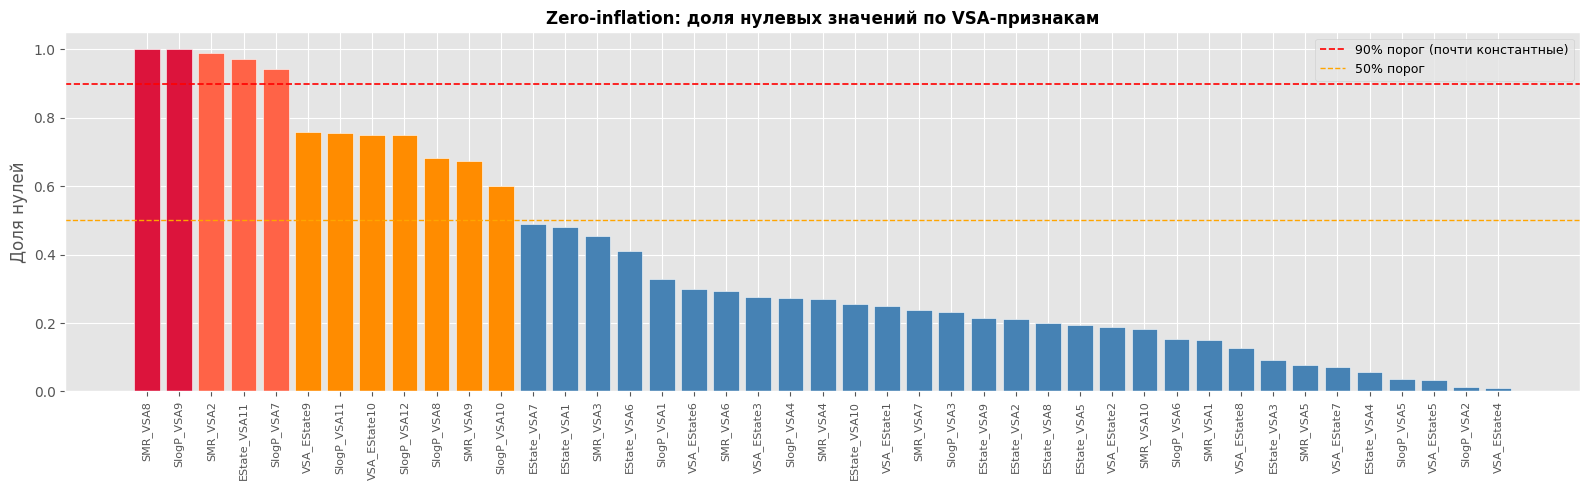

Константные (100% нулей) : 2
Почти константные (>90%) : 5
Топ-10 по доле нулей:
SMR_VSA8        1.000
SlogP_VSA9      1.000
SMR_VSA2        0.989
EState_VSA11    0.972
SlogP_VSA7      0.944
VSA_EState9     0.759
SlogP_VSA11     0.755
VSA_EState10    0.750
SlogP_VSA12     0.748
SlogP_VSA8      0.683


In [33]:
# ── G4: Zero-inflation — доля нулей ──────────────────────────────────────
zero_frac = (train[FEATURES_VSA] == 0).mean().sort_values(ascending=False)

colors_zi = ['crimson' if v == 1.0 else 'tomato' if v >= 0.9
             else 'darkorange' if v >= 0.5 else 'steelblue' for v in zero_frac.values]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(zero_frac)), zero_frac.values, color=colors_zi, edgecolor='white', linewidth=0.4)
ax.axhline(0.9, color='red',    linestyle='--', linewidth=1.2, label='90% порог (почти константные)')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=1.0, label='50% порог')
ax.set_xticks(range(len(zero_frac)))
ax.set_xticklabels(zero_frac.index, rotation=90, fontsize=8)
ax.set_ylabel('Доля нулей')
ax.set_title('Zero-inflation: доля нулевых значений по VSA-признакам', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Константные (100% нулей) : {(zero_frac == 1.0).sum()}')
print(f'Почти константные (>90%) : {(zero_frac >= 0.9).sum()}')
print(f'Топ-10 по доле нулей:')
print(zero_frac.head(10).round(3).to_string())

In [34]:
# ── G4: Константные и почти-константные признаки ─────────────────────────
constant_feats_vsa = [c for c in FEATURES_VSA if train[c].std() == 0]
print(f'Константные (std = 0): {constant_feats_vsa}')

USABLE_FEATURES_VSA = [c for c in FEATURES_VSA if c not in constant_feats_vsa]
print(f'Признаков после отсева константных: {len(USABLE_FEATURES_VSA)} / {len(FEATURES_VSA)}')

# Почти-константные среди нестандартных
sel_vsa = VarianceThreshold(threshold=0.01)
sel_vsa.fit(train[USABLE_FEATURES_VSA])
low_var_vsa = [USABLE_FEATURES_VSA[i] for i in np.where(~sel_vsa.get_support())[0]]
print(f'Почти константные (var < 0.01): {low_var_vsa}')

Константные (std = 0): ['SMR_VSA8', 'SlogP_VSA9']
Признаков после отсева константных: 41 / 43
Почти константные (var < 0.01): []


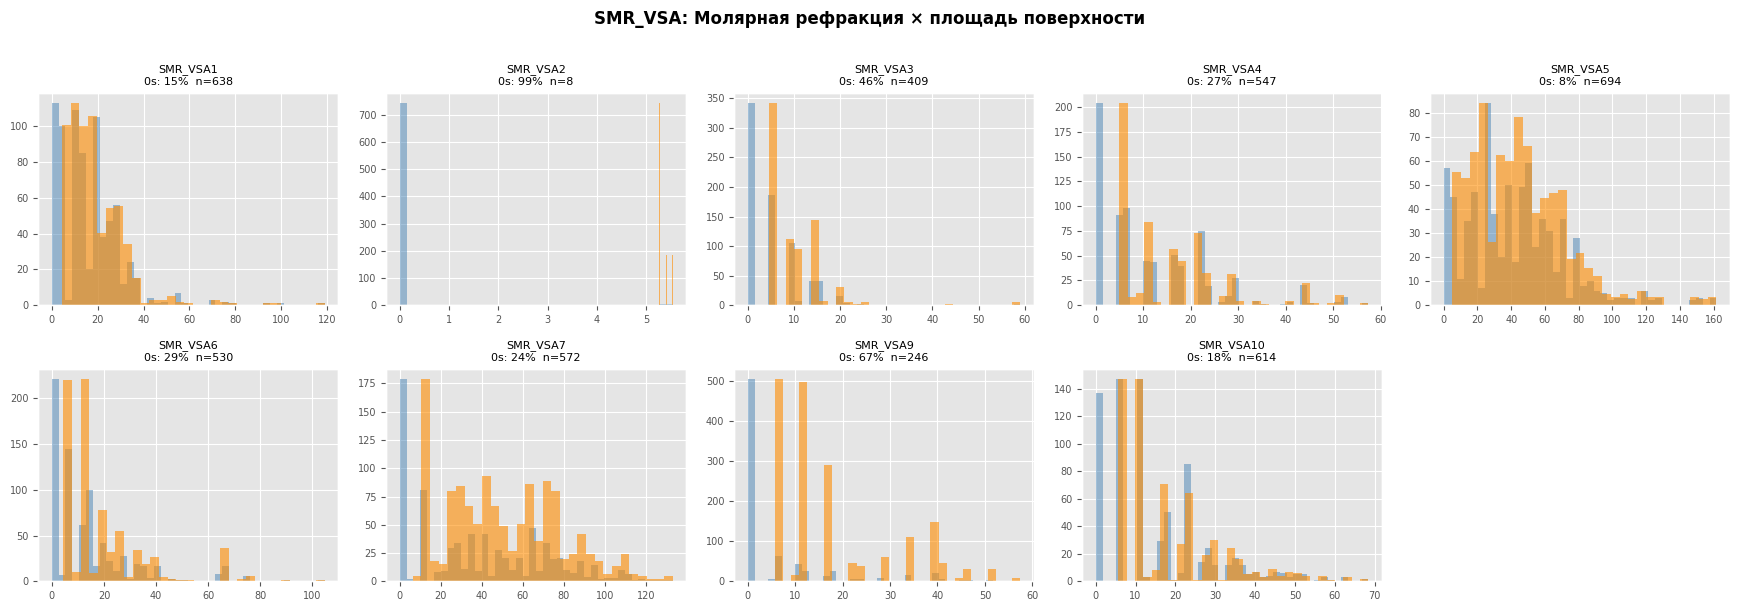

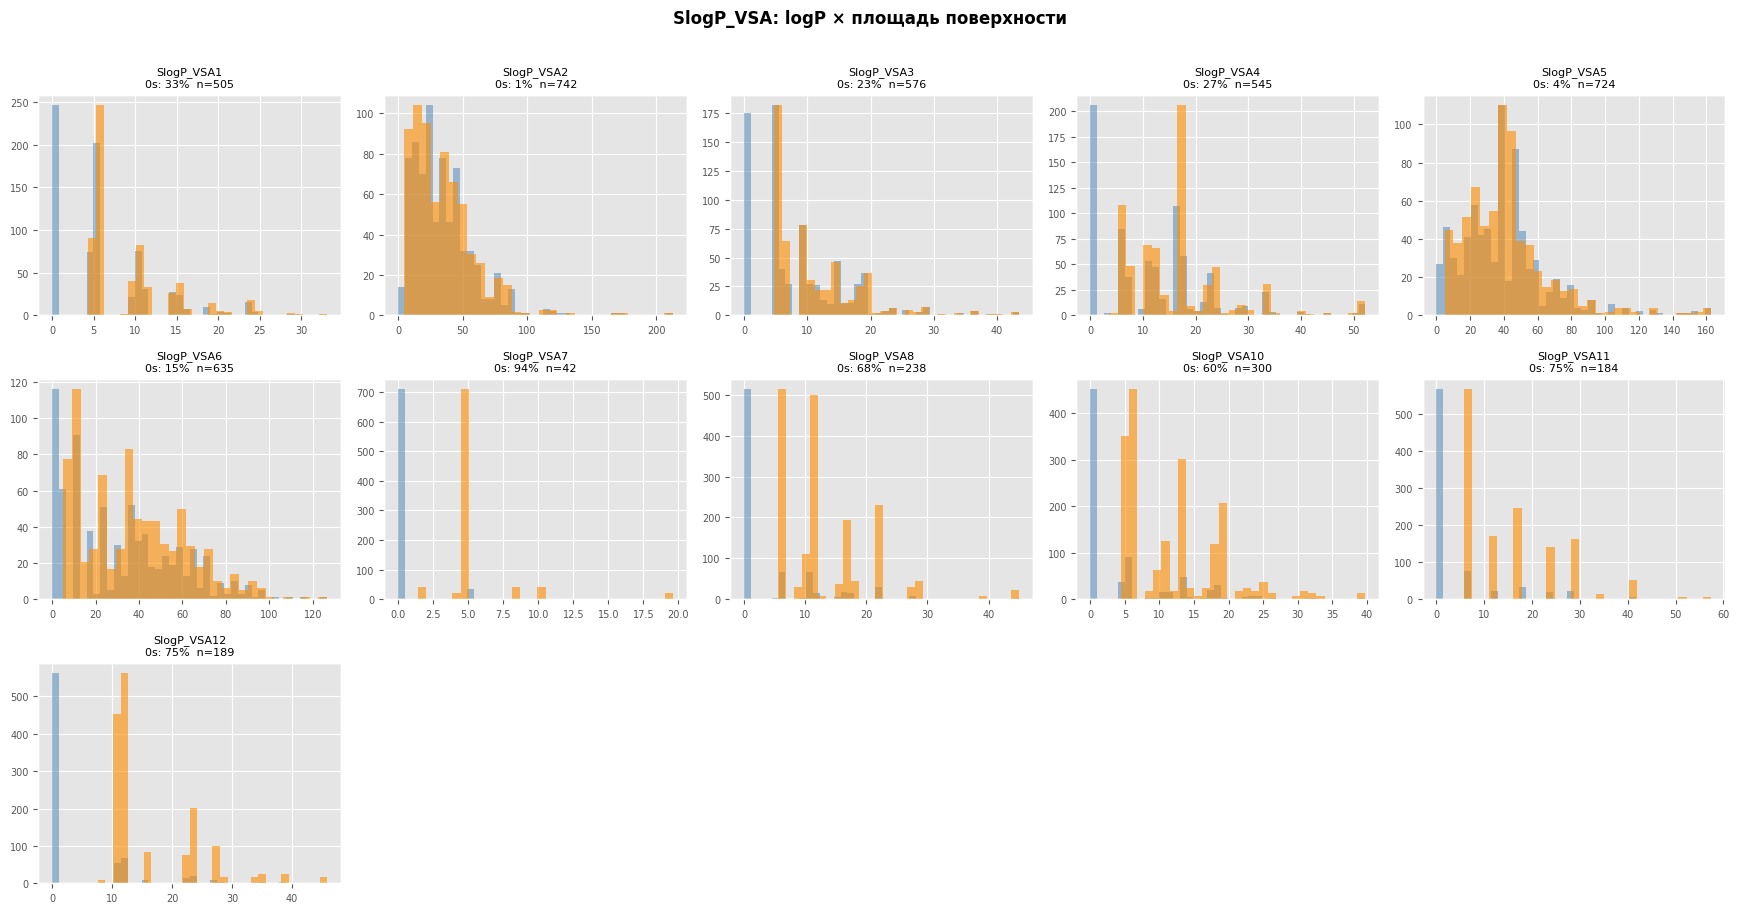

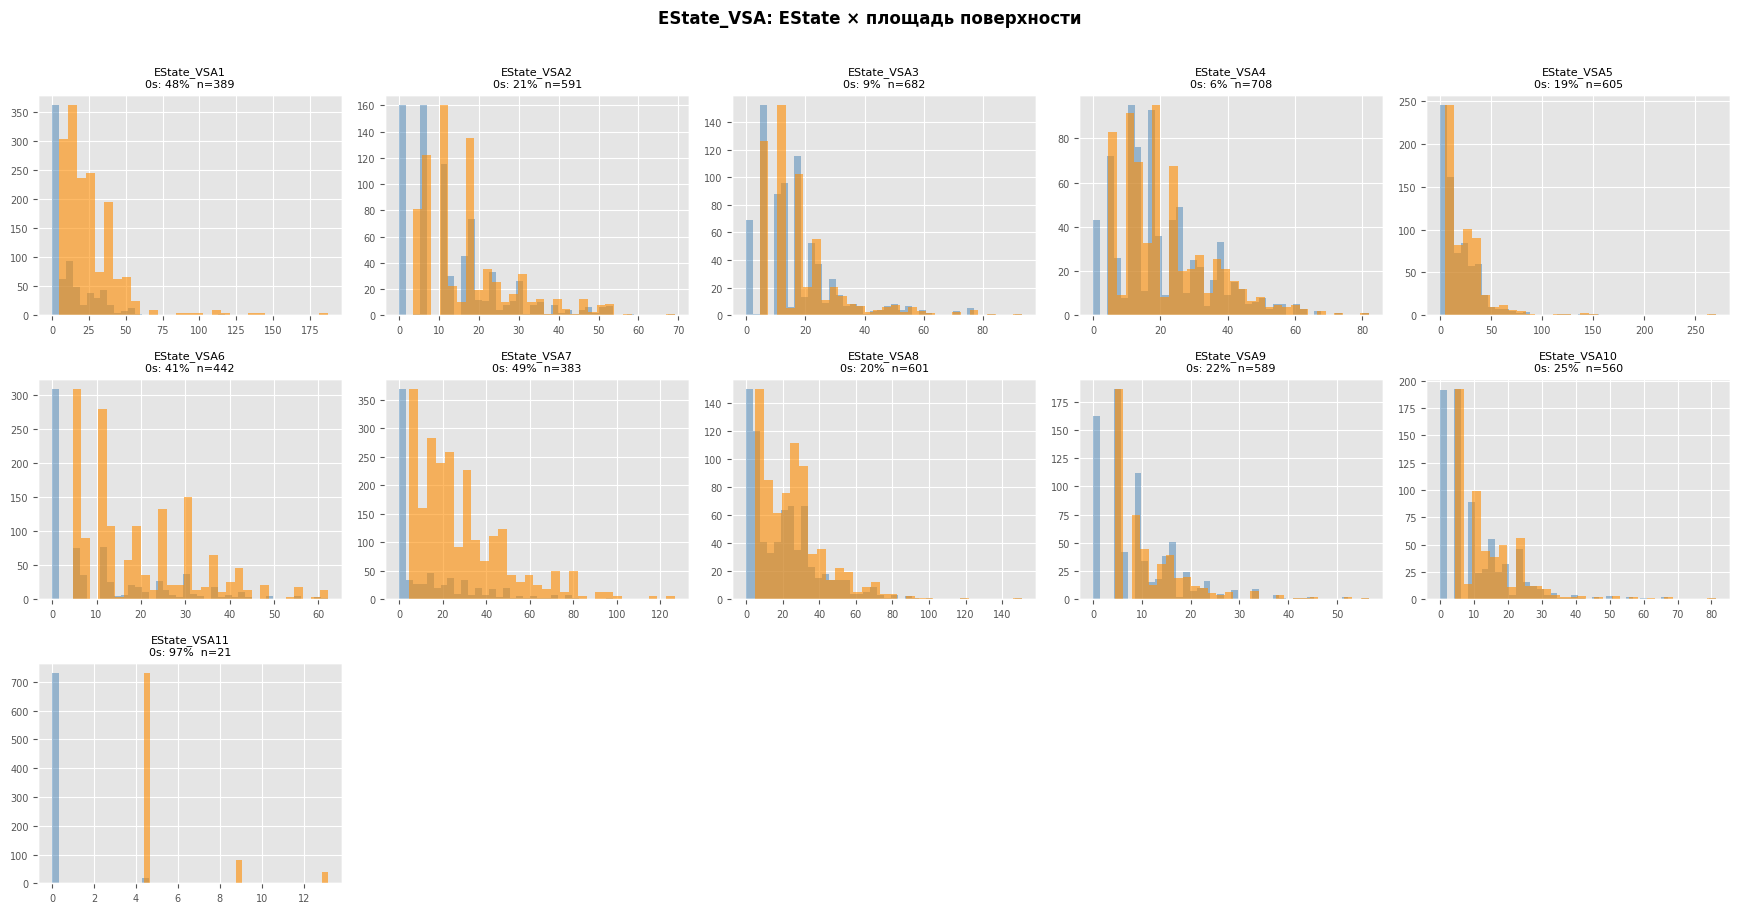

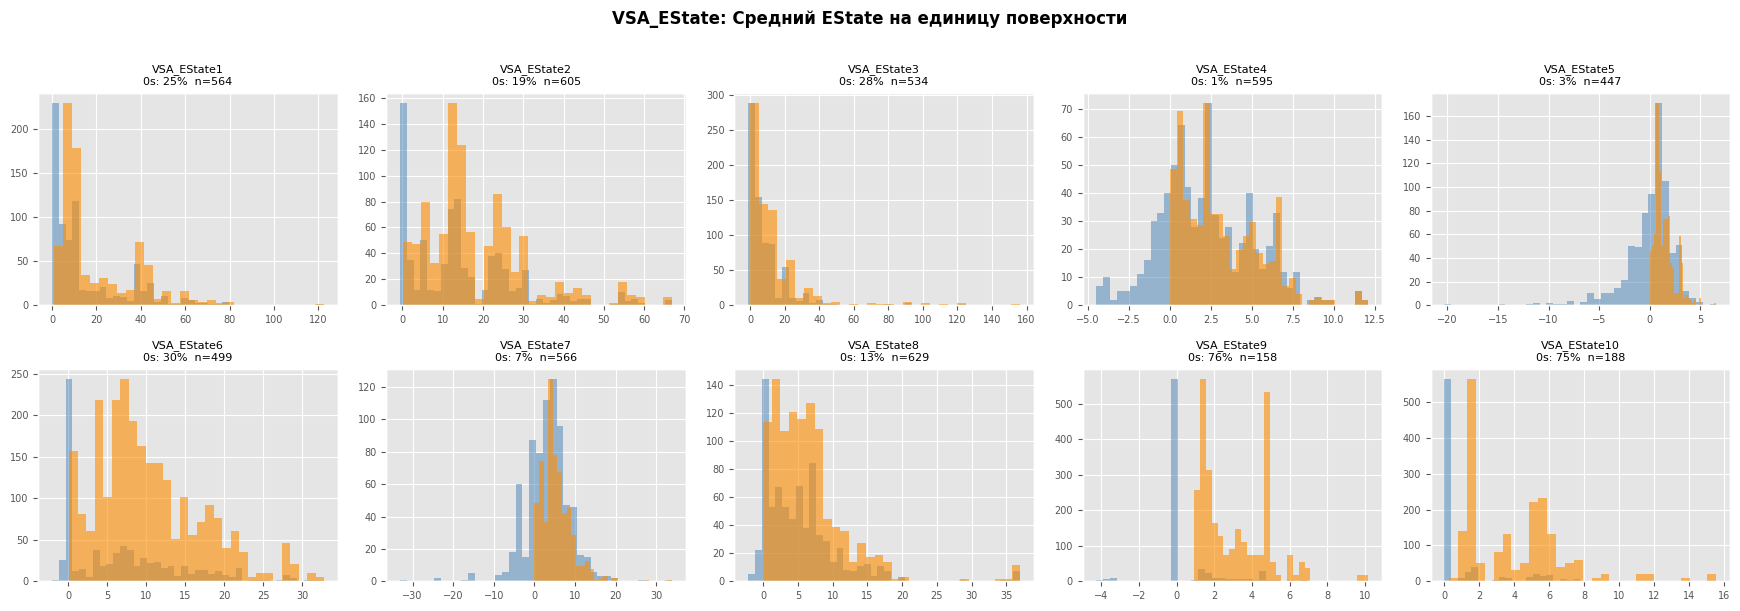

In [35]:
# ── G4: Распределения ────────────────────────────────────────────────────
def plot_subgroup(feats, title, ncols=5):
    feats = [f for f in feats if f in USABLE_FEATURES_VSA]
    nrows = int(np.ceil(len(feats) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3))
    axes = np.array(axes).flatten()
    for i, feat in enumerate(feats):
        ax = axes[i]
        data = train[feat]
        nonzero = data[data > 0]
        ax.hist(data, bins=40, color='steelblue', alpha=0.5, label='all')
        if len(nonzero) > 0:
            ax2 = ax.twinx()
            ax2.hist(nonzero, bins=30, color='darkorange', alpha=0.6, label='non-zero')
            ax2.set_yticks([])
        zero_pct = (data == 0).mean() * 100
        ax.set_title(f'{feat}\n0s: {zero_pct:.0f}%  n={len(nonzero)}', fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_subgroup(SMR_FEATS,    'SMR_VSA: Молярная рефракция × площадь поверхности')
plot_subgroup(SLOGP_FEATS,  'SlogP_VSA: logP × площадь поверхности')
plot_subgroup(ESTATE_FEATS, 'EState_VSA: EState × площадь поверхности')
plot_subgroup(VSA_E_FEATS,  'VSA_EState: Средний EState на единицу поверхности')

In [36]:
# ── G4: Корреляционный анализ ─────────────────────────────────────────────
corr_vsa = train[USABLE_FEATURES_VSA].corr()
upper_vsa = corr_vsa.where(np.triu(np.ones_like(corr_vsa, dtype=bool), k=1))
high_corr_vsa = [(c, r, upper_vsa.loc[r, c])
                 for c in upper_vsa.columns for r in upper_vsa.index
                 if upper_vsa.loc[r, c] > 0.9]
print(f'Пары с |Pearson r| > 0.90: {len(high_corr_vsa)}')
for c1, c2, val in sorted(high_corr_vsa, key=lambda x: -x[2]):
    print(f'  {c1:25s} — {c2:25s}: {val:.3f}')

Пары с |Pearson r| > 0.90: 4
  SlogP_VSA6                — SMR_VSA7                 : 0.962
  VSA_EState6               — SlogP_VSA6               : 0.926
  SlogP_VSA11               — SMR_VSA9                 : 0.908
  VSA_EState6               — SMR_VSA7                 : 0.906


In [37]:
# ── G4: Инженерия агрегированных признаков ───────────────────────────────
def engineer_vsa_features(df):
    """Создаёт агрегированные VSA-фичи на основе физико-химического смысла."""
    d = df.copy()

    smr  = [c for c in SMR_FEATS   if c in df.columns and df[c].std() > 0]
    slgp = [c for c in SLOGP_FEATS if c in df.columns and df[c].std() > 0]
    est  = [c for c in ESTATE_FEATS if c in df.columns]
    vest = [c for c in VSA_E_FEATS  if c in df.columns]

    # 1. Общая площадь поверхности по каждому семейству
    d['vsa_smr_total']    = df[smr].sum(axis=1)
    d['vsa_slogp_total']  = df[slgp].sum(axis=1)
    d['vsa_estate_total'] = df[est].sum(axis=1)

    # 2. Полярная поверхность — бины EState_VSA >= 8 (гидрофильные атомы)
    polar_bins = [c for c in est if int(c.split('EState_VSA')[1]) >= 8]
    d['vsa_polar_surface'] = df[polar_bins].sum(axis=1) if polar_bins else 0

    # 3. Гидрофобная площадь — бины SlogP_VSA >= 7 (высокий вклад logP)
    hydrophob_bins = [c for c in slgp if int(c.split('SlogP_VSA')[1]) >= 7]
    d['vsa_hydrophobic'] = df[hydrophob_bins].sum(axis=1) if hydrophob_bins else 0

    # 4. Соотношение полярной к общей площади (аналог нормированного TPSA)
    total = d['vsa_estate_total']
    d['vsa_polar_fraction'] = d['vsa_polar_surface'] / (total + 1e-6)

    # 5. Дисперсия по бинам (мера равномерности распределения свойства по поверхности)
    d['vsa_smr_std']    = df[smr].std(axis=1)
    d['vsa_slogp_std']  = df[slgp].std(axis=1)
    d['vsa_estate_std'] = df[est].std(axis=1)

    # 6. Число ненулевых бинов (сложность/разнообразие распределения по поверхности)
    d['vsa_smr_nonzero']    = (df[smr] > 0).sum(axis=1)
    d['vsa_slogp_nonzero']  = (df[slgp] > 0).sum(axis=1)
    d['vsa_estate_nonzero'] = (df[est] > 0).sum(axis=1)

    return d

ENGINEERED_VSA = [
    'vsa_smr_total', 'vsa_slogp_total', 'vsa_estate_total',
    'vsa_polar_surface', 'vsa_hydrophobic', 'vsa_polar_fraction',
    'vsa_smr_std', 'vsa_slogp_std', 'vsa_estate_std',
    'vsa_smr_nonzero', 'vsa_slogp_nonzero', 'vsa_estate_nonzero'
]

train = engineer_vsa_features(train)
test  = engineer_vsa_features(test)
print(f"Добавлено {len(ENGINEERED_VSA)} агрегированных признаков.")

# Корреляция инженерных признаков с таргетами
print('\nSpearman r (инженерные признаки vs таргеты):')
for feat in ENGINEERED_VSA:
    line = f'  {feat:30s}:'
    for t in TARGETS:
        r, p = spearmanr(train[feat], train[t])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '  '
        line += f'  {t}={r:+.3f}{sig}'
    print(line)

Добавлено 12 агрегированных признаков.

Spearman r (инженерные признаки vs таргеты):
  vsa_smr_total                 :  IC50=-0.073*  CC50=-0.262***  SI=-0.111**
  vsa_slogp_total               :  IC50=-0.073*  CC50=-0.262***  SI=-0.111**
  vsa_estate_total              :  IC50=-0.073*  CC50=-0.262***  SI=-0.111**
  vsa_polar_surface             :  IC50=-0.177***  CC50=-0.181***  SI=+0.050  
  vsa_hydrophobic               :  IC50=+0.137***  CC50=-0.066    SI=-0.163***
  vsa_polar_fraction            :  IC50=-0.119**  CC50=+0.048    SI=+0.126***
  vsa_smr_std                   :  IC50=-0.126***  CC50=-0.278***  SI=-0.072*
  vsa_slogp_std                 :  IC50=-0.107**  CC50=-0.177***  SI=-0.047  
  vsa_estate_std                :  IC50=-0.107**  CC50=-0.213***  SI=-0.029  
  vsa_smr_nonzero               :  IC50=-0.034    CC50=-0.084*  SI=-0.036  
  vsa_slogp_nonzero             :  IC50=+0.082*  CC50=-0.099**  SI=-0.135***
  vsa_estate_nonzero            :  IC50=+0.020    CC50=-0.117

In [38]:
# ── G4: Distribution Shift (KS-тест) ─────────────────────────────────────
drift_report_g4 = detect_drift(train, test, USABLE_FEATURES_VSA)
shifted_vsa = drift_report_g4[drift_report_g4['drift'] == True]
print(f'Признаков со значимым distribution shift: {len(shifted_vsa)} / {len(USABLE_FEATURES_VSA)}')
if len(shifted_vsa) > 0:
    display(shifted_vsa.sort_values('ks_statistic', ascending=False))
else:
    print('Distribution shift не обнаружен (все KS-тесты: p > 0.05)')

Признаков со значимым distribution shift: 0 / 41
Distribution shift не обнаружен (все KS-тесты: p > 0.05)


In [39]:
# ── G4: Удаление проблемных признаков ────────────────────────────────────
# Константные: SMR_VSA8, SlogP_VSA9 (100% нулей)
# Почти-константные (рекомендуется): SMR_VSA2 (98.9% нулей), EState_VSA11 (97.2% нулей)
# Высококоррелированная пара: SlogP_VSA6 ↔ SMR_VSA7 (r=0.962) → удаляем SlogP_VSA6

VSA_TO_DROP = constant_feats_vsa + ['SMR_VSA2', 'EState_VSA11', 'SlogP_VSA6']
VSA_TO_DROP = [f for f in VSA_TO_DROP if f in train.columns]  # на случай дублей

train = train.drop(columns=VSA_TO_DROP, errors='ignore')
test  = test.drop(columns=VSA_TO_DROP, errors='ignore')
FEATURES_VSA = [f for f in FEATURES_VSA if f not in VSA_TO_DROP]

print(f"Удалено {len(VSA_TO_DROP)}: {VSA_TO_DROP}")
print(f"Индивидуальных VSA-признаков: {len(FEATURES_VSA)}, агрегированных: {len(ENGINEERED_VSA)}")

Удалено 5: ['SMR_VSA8', 'SlogP_VSA9', 'SMR_VSA2', 'EState_VSA11', 'SlogP_VSA6']
Индивидуальных VSA-признаков: 38, агрегированных: 12


### Выводы G4 — VSA Surface Descriptors

| Проблема | Признаки | Действие |
|----------|----------|----------|
| Константные (100% нулей) | `SMR_VSA8`, `SlogP_VSA9` | Удалены |
| Почти константные (>97% нулей) | `SMR_VSA2`, `EState_VSA11` | Удалены |
| Высокая корреляция (r=0.962) | `SlogP_VSA6` ↔ `SMR_VSA7` | Удалён `SlogP_VSA6` |

Distribution shift отсутствует. Добавлено **12 агрегированных признаков** (`vsa_*`).

## Группа 5 — Функциональные группы (fr_*)

85 бинарных признаков, кодирующих наличие химических функциональных групп.

In [40]:
# ── G5: Определение признаков ─────────────────────────────────────────────

GROUP_NAME_G5 = r'Функциональные группы (fr_*)'
FEATURES_G5   = train.columns[train.columns.str.contains('^fr_')].to_list()
TARGETS_G5    = TARGETS  # используем глобальный список

# Работаем на копии — в оригинале train перезаписывался (train = train[FEATURES])
train_fr = train[FEATURES_G5].copy()

print(f"Всего fr_* признаков: {len(FEATURES_G5)}")
print(train.columns[train.columns.str.contains('^fr_')])

Всего fr_* признаков: 85
Index(['fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN', 'fr_Ar_COO',
       'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2', 'fr_C_O',
       'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0', 'fr_NH1',
       'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2',
       'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate',
       'fr_alkyl_halide', 'fr_allylic_oxid', 'fr_amide', 'fr_amidine',
       'fr_aniline', 'fr_aryl_methyl', 'fr_azide', 'fr_azo', 'fr_barbitur',
       'fr_benzene', 'fr_benzodiazepine', 'fr_bicyclic', 'fr_diazo',
       'fr_dihydropyridine', 'fr_epoxide', 'fr_ester', 'fr_ether', 'fr_furan',
       'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone', 'fr_imidazole',
       'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone',
       'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy',
       'fr_morpholine', 'fr_nitrile', 'fr_nitro', 'fr_nitro_arom',
       'fr_nitro_arom_nonortho', 'fr_ni

In [41]:
# ── G5: Анализ пропусков ─────────────────────────────────────────────────
missing_percent = (train_fr.isnull().sum() / len(train_fr)) * 100
missing_df_g5 = pd.DataFrame({
    'column': missing_percent.index,
    'missing_%': missing_percent.values,
    'missing_abs': train_fr.isnull().sum().values
})
missing_df_g5 = missing_df_g5[missing_df_g5['missing_%'] > 0]

if len(missing_df_g5) == 0:
    print('Пропуски в группе отсутствуют.')
else:
    print(missing_df_g5)

Пропуски в группе отсутствуют.


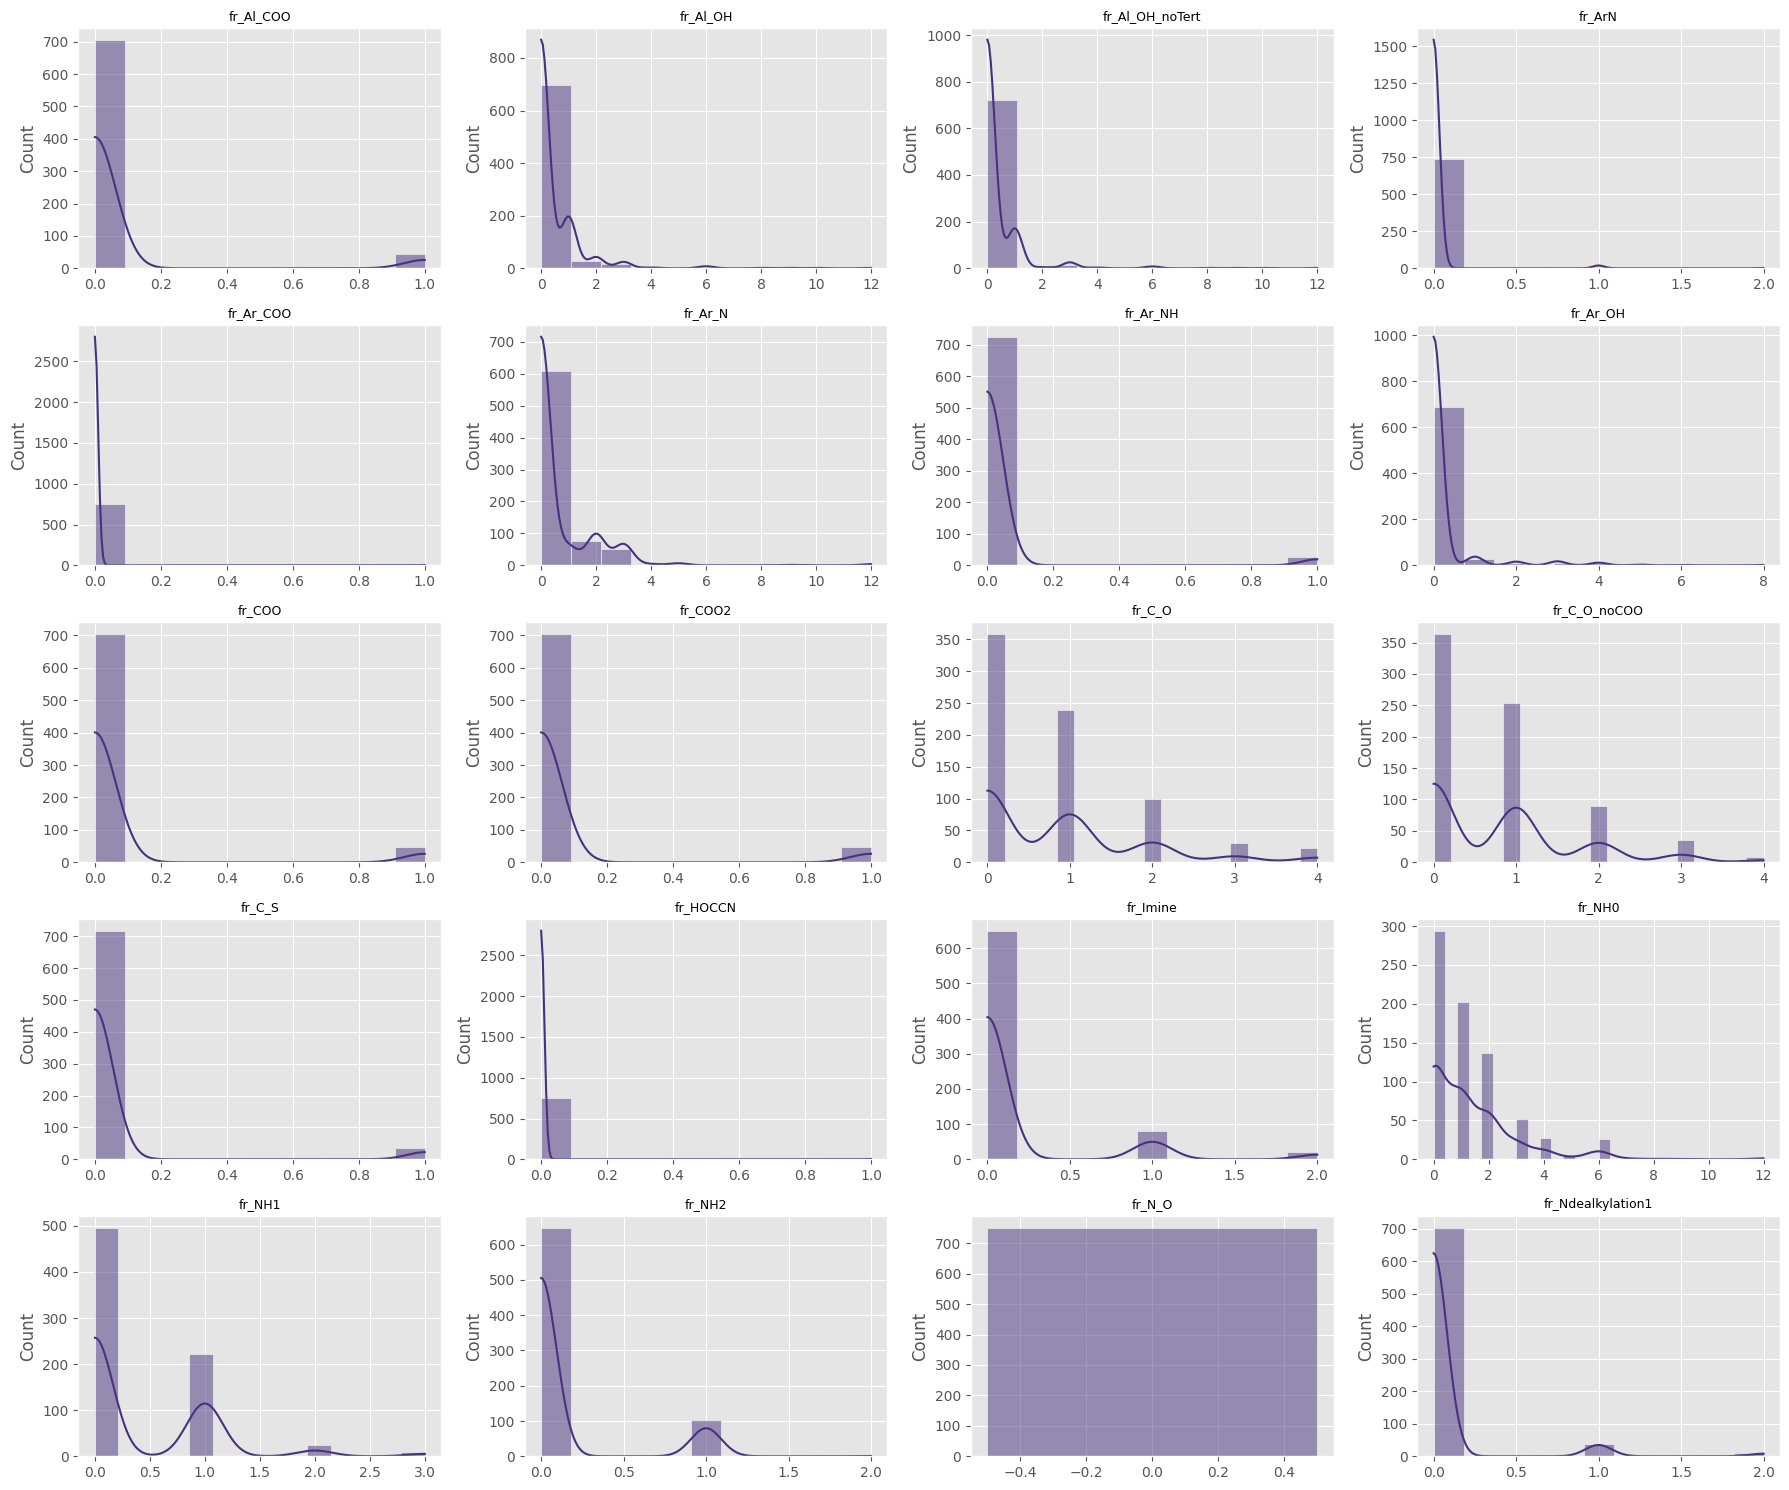

In [42]:
# ── G5: Распределения и боксплоты (первые 20 для компактности) ────────────
n_cols = 4
n_rows = int(np.ceil(len(train_fr.columns[:20]) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()
for i, feat in enumerate(train_fr.columns[:20]):
    ax = axes[i]
    sns.histplot(train_fr[feat], kde=True, ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [43]:
# ── G5: VarianceThreshold — убираем почти-константные (порог 0.01) ────────
selector = VarianceThreshold(0.01)
train_fr = pd.DataFrame(
    selector.fit_transform(train_fr),
    columns=selector.get_feature_names_out(),
    index=train.index
)
print(f'Осталось {train_fr.shape[1]} из {len(FEATURES_G5)} признаков')

Осталось 57 из 85 признаков


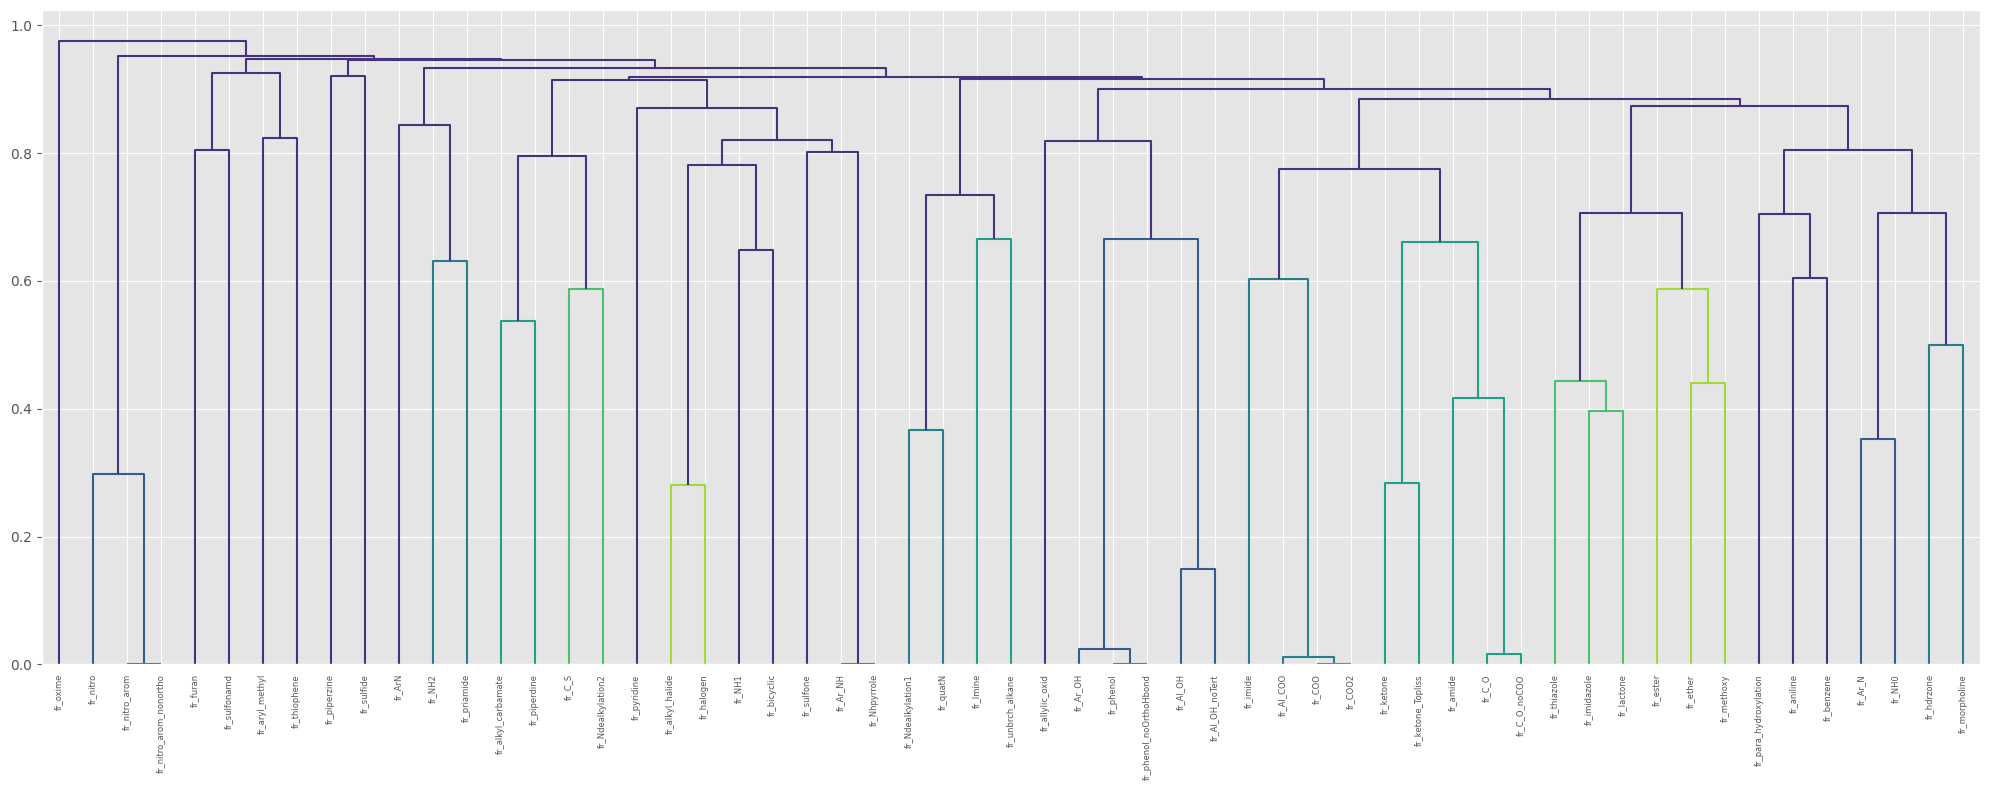

In [44]:
# ── G5: Корреляция Спирмена и иерархическая кластеризация ────────────────
corr = train_fr.corr(method='spearman').abs()

distance_matrix = 1 - corr
dist_array = squareform(distance_matrix)
Z_g5 = linkage(dist_array, method='average')

plt.figure(figsize=(20, 8))
dendrogram(Z_g5, labels=train_fr.columns, leaf_rotation=90)
plt.tight_layout()
plt.show()

In [45]:
# ── G5: Кластеры с t=0.2 (r >= 0.8) ─────────────────────────────────────
clusters_g5 = fcluster(Z_g5, t=0.2, criterion='distance')

cluster_dict_g5 = {}
for feature, cluster_id in zip(train_fr.columns, clusters_g5):
    cluster_dict_g5.setdefault(cluster_id, []).append(feature)

cluster_ambiguous_g5 = [cluster for cluster in cluster_dict_g5.values() if len(cluster) > 1]
cluster_ambiguous_g5

[['fr_Al_COO', 'fr_COO', 'fr_COO2'],
 ['fr_Al_OH', 'fr_Al_OH_noTert'],
 ['fr_Ar_NH', 'fr_Nhpyrrole'],
 ['fr_Ar_OH', 'fr_phenol', 'fr_phenol_noOrthoHbond'],
 ['fr_C_O', 'fr_C_O_noCOO'],
 ['fr_nitro_arom', 'fr_nitro_arom_nonortho']]

In [46]:
# ── G5: Выбор лучшего признака из каждого кластера ───────────────────────
# Критерий: наибольшая сумма |Spearman r| с таргетами

cluster_features_g5 = [
    max(
        {col: sum(abs(spearmanr(train_fr[col], train[tar])[0]) for tar in TARGETS_G5)
         for col in cluster}.items(),
        key=lambda x: x[1]
    )
    for cluster in cluster_ambiguous_g5
]
cluster_features_g5

[('fr_Al_COO', np.float64(0.19236449971084157)),
 ('fr_Al_OH', np.float64(0.11305536915584319)),
 ('fr_Ar_NH', np.float64(0.10912739919625829)),
 ('fr_phenol', np.float64(0.30391398406503684)),
 ('fr_C_O', np.float64(0.32439688170571124)),
 ('fr_nitro_arom', np.float64(0.12223415034960347))]

In [47]:
# Применяем удаление к копии train_fr, затем — к основным train/test
train_fr = train_fr.drop(
    set(sum(cluster_ambiguous_g5, start=[])) - dict(cluster_features_g5).keys(),
    axis=1
)
print(f'Осталось {train_fr.shape[1]} из {len(FEATURES_G5)} признаков')
print(f'\nОставленные признаки:\n {train_fr.columns}')

# Удаляем из основных датафреймов
FR_FINAL = train_fr.columns.tolist()
FR_TO_DROP = [f for f in FEATURES_G5 if f not in FR_FINAL]
train = train.drop(columns=FR_TO_DROP, errors='ignore')
test  = test.drop(columns=FR_TO_DROP, errors='ignore')

Осталось 49 из 85 признаков

Оставленные признаки:
 Index(['fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_N', 'fr_Ar_NH', 'fr_C_O',
       'fr_C_S', 'fr_Imine', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ndealkylation1',
       'fr_Ndealkylation2', 'fr_alkyl_carbamate', 'fr_alkyl_halide',
       'fr_allylic_oxid', 'fr_amide', 'fr_aniline', 'fr_aryl_methyl',
       'fr_benzene', 'fr_bicyclic', 'fr_ester', 'fr_ether', 'fr_furan',
       'fr_halogen', 'fr_hdrzone', 'fr_imidazole', 'fr_imide', 'fr_ketone',
       'fr_ketone_Topliss', 'fr_lactone', 'fr_methoxy', 'fr_morpholine',
       'fr_nitro', 'fr_nitro_arom', 'fr_oxime', 'fr_para_hydroxylation',
       'fr_phenol', 'fr_piperdine', 'fr_piperzine', 'fr_priamide',
       'fr_pyridine', 'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone',
       'fr_thiazole', 'fr_thiophene', 'fr_unbrch_alkane'],
      dtype='object')


### Выводы G5 — Функциональные группы (fr_*)

| Шаг | До | После |
|-----|----|-------|
| Исходно | 85 | — |
| VarianceThreshold(0.01) — редкие группы (<1% молекул) | 85 | 57 |
| Иерархическая кластеризация (Спирмен, t=0.2) | 57 | 49 |

**Логика отбора:** бинарные признаки `fr_*` часто дублируют друг друга — одна функциональная группа является подструктурой другой (например, `fr_amide` и `fr_amidine`). Иерархическая кластеризация по матрице Спирмена (порог 1−|r| < 0.2, т.е. |r| > 0.8) объединяет такие группы в кластеры; из каждого кластера оставляется один признак с наибольшей суммарной корреляцией с таргетами.

**Итого: 49 признаков** из 85 исходных.

## Группа 6 — Специфические дескрипторы (EState, BCUT2D, FpDensityMorgan)

15 признаков: EState-индексы (4), BCUT2D спектральные дескрипторы (8), плотности отпечатков Моргана (3).

In [48]:
# ── G6: Определение признаков ─────────────────────────────────────────────

ESTATE_IDX = ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex']
BCUT2D     = sorted([c for c in train.columns if c.startswith('BCUT2D_')])
FPDENS     = sorted([c for c in train.columns if c.startswith('FpDensityMorgan')])
SPEC_DESCR = ESTATE_IDX + BCUT2D + FPDENS
DESCRIPTORS_GROUP = 'Specific Descriptors'

print(f'Всего признаков в группе: {len(SPEC_DESCR)}')
print(f'  EState-индексы : {len(ESTATE_IDX)}')
print(f'  BCUT2D         : {len(BCUT2D)}')
print(f'  FpDensityMorgan: {len(FPDENS)}')

Всего признаков в группе: 15
  EState-индексы : 4
  BCUT2D         : 8
  FpDensityMorgan: 3


In [49]:
# ── G6: Критическая находка — дубликат MaxAbsEStateIndex ─────────────────
are_identical = (train['MaxAbsEStateIndex'] == train['MaxEStateIndex']).all()
corr_max = train['MaxAbsEStateIndex'].corr(train['MaxEStateIndex'])
print(f'MaxAbsEStateIndex == MaxEStateIndex (точно): {are_identical}')
print(f'Pearson r: {corr_max:.6f}')
print(f'Min(MaxEStateIndex): {train["MaxEStateIndex"].min():.4f}')
print(f'Молекул с MaxEStateIndex < 0: {(train["MaxEStateIndex"] < 0).sum()}')
print(f'\nВывод: MaxAbsEStateIndex — полный дубликат → подлежит удалению.')

MaxAbsEStateIndex == MaxEStateIndex (точно): True
Pearson r: 1.000000
Min(MaxEStateIndex): 2.3219
Молекул с MaxEStateIndex < 0: 0

Вывод: MaxAbsEStateIndex — полный дубликат → подлежит удалению.


In [50]:
# ── G6: Анализ пропусков (BCUT2D) ─────────────────────────────────────────
missing_g6 = train[SPEC_DESCR].isnull().sum()
missing_pct_g6 = missing_g6 / len(train) * 100
has_missing_g6 = pd.DataFrame({'missing_abs': missing_g6,
                                'missing_%': missing_pct_g6.round(3)})
has_missing_g6 = has_missing_g6[has_missing_g6['missing_abs'] > 0]

print(f'Обнаружены пропуски в {len(has_missing_g6)} признаках:')
print(has_missing_g6.to_string())

nan_rows = train[train[BCUT2D[0]].isna()]
print(f'\nСтроки train с NaN в BCUT2D (всего: {len(nan_rows)}):')
print(nan_rows[['IC50', 'CC50', 'SI']].to_string())

nan_test_g6 = test[test[BCUT2D[0]].isna()]
print(f'NaN в BCUT2D в test: {len(nan_test_g6)} строк')

Обнаружены пропуски в 8 признаках:
                missing_abs  missing_%
BCUT2D_CHGHI              2      0.266
BCUT2D_CHGLO              2      0.266
BCUT2D_LOGPHI             2      0.266
BCUT2D_LOGPLOW            2      0.266
BCUT2D_MRHI               2      0.266
BCUT2D_MRLOW              2      0.266
BCUT2D_MWHI               2      0.266
BCUT2D_MWLOW              2      0.266

Строки train с NaN в BCUT2D (всего: 2):
            IC50         CC50         SI
331    25.171788  1878.491646  74.626866
500  1199.174968  1199.174968   1.000000
NaN в BCUT2D в test: 1 строк


In [51]:
# ── G6: Медианная импутация BCUT2D ───────────────────────────────────────
for col in BCUT2D:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)
print("Пропуски в BCUT2D заполнены медианами train.")

Пропуски в BCUT2D заполнены медианами train.


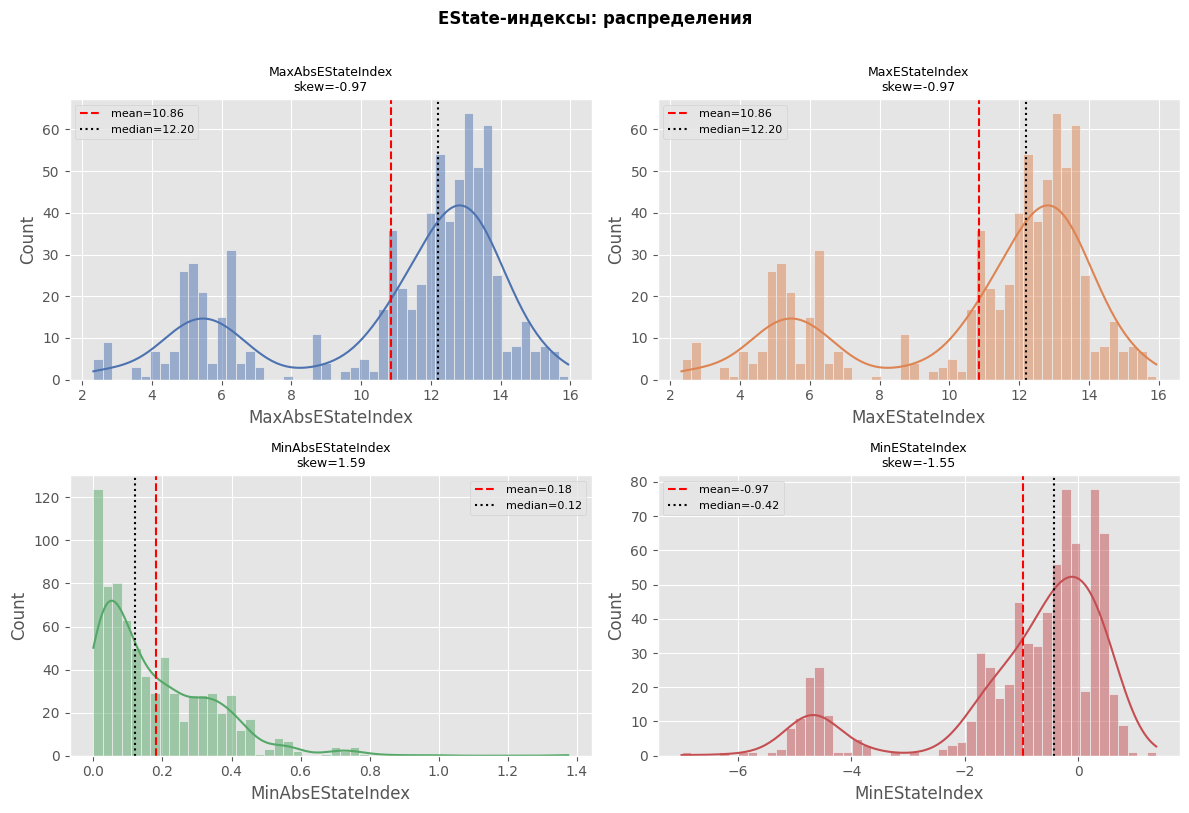

Описательная статистика EState-индексов:
       MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex
count           751.0000        751.0000           751.0000        751.0000
mean             10.8601         10.8601             0.1801         -0.9719
std               3.3473          3.3473             0.1692          1.5945
min               2.3219          2.3219             0.0000         -6.9928
25%               8.9210          8.9210             0.0485         -1.3338
50%              12.1975         12.1975             0.1214         -0.4195
75%              13.2142         13.2142             0.2910          0.0725
max              15.9335         15.9335             1.3746          1.3746


In [52]:
# ── G6: Распределения EState-индексов ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors_g6 = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

for i, (feat, ax) in enumerate(zip(ESTATE_IDX, axes.flatten())):
    s = train[feat]
    sns.histplot(s, bins=50, kde=True, ax=ax, color=colors_g6[i])
    ax.axvline(s.mean(),   color='red',   linestyle='--', linewidth=1.5,
               label=f'mean={s.mean():.2f}')
    ax.axvline(s.median(), color='black', linestyle=':',  linewidth=1.5,
               label=f'median={s.median():.2f}')
    ax.set_title(f'{feat}\nskew={s.skew():.2f}', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('EState-индексы: распределения', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Описательная статистика EState-индексов:')
print(train[ESTATE_IDX].describe().round(4).to_string())

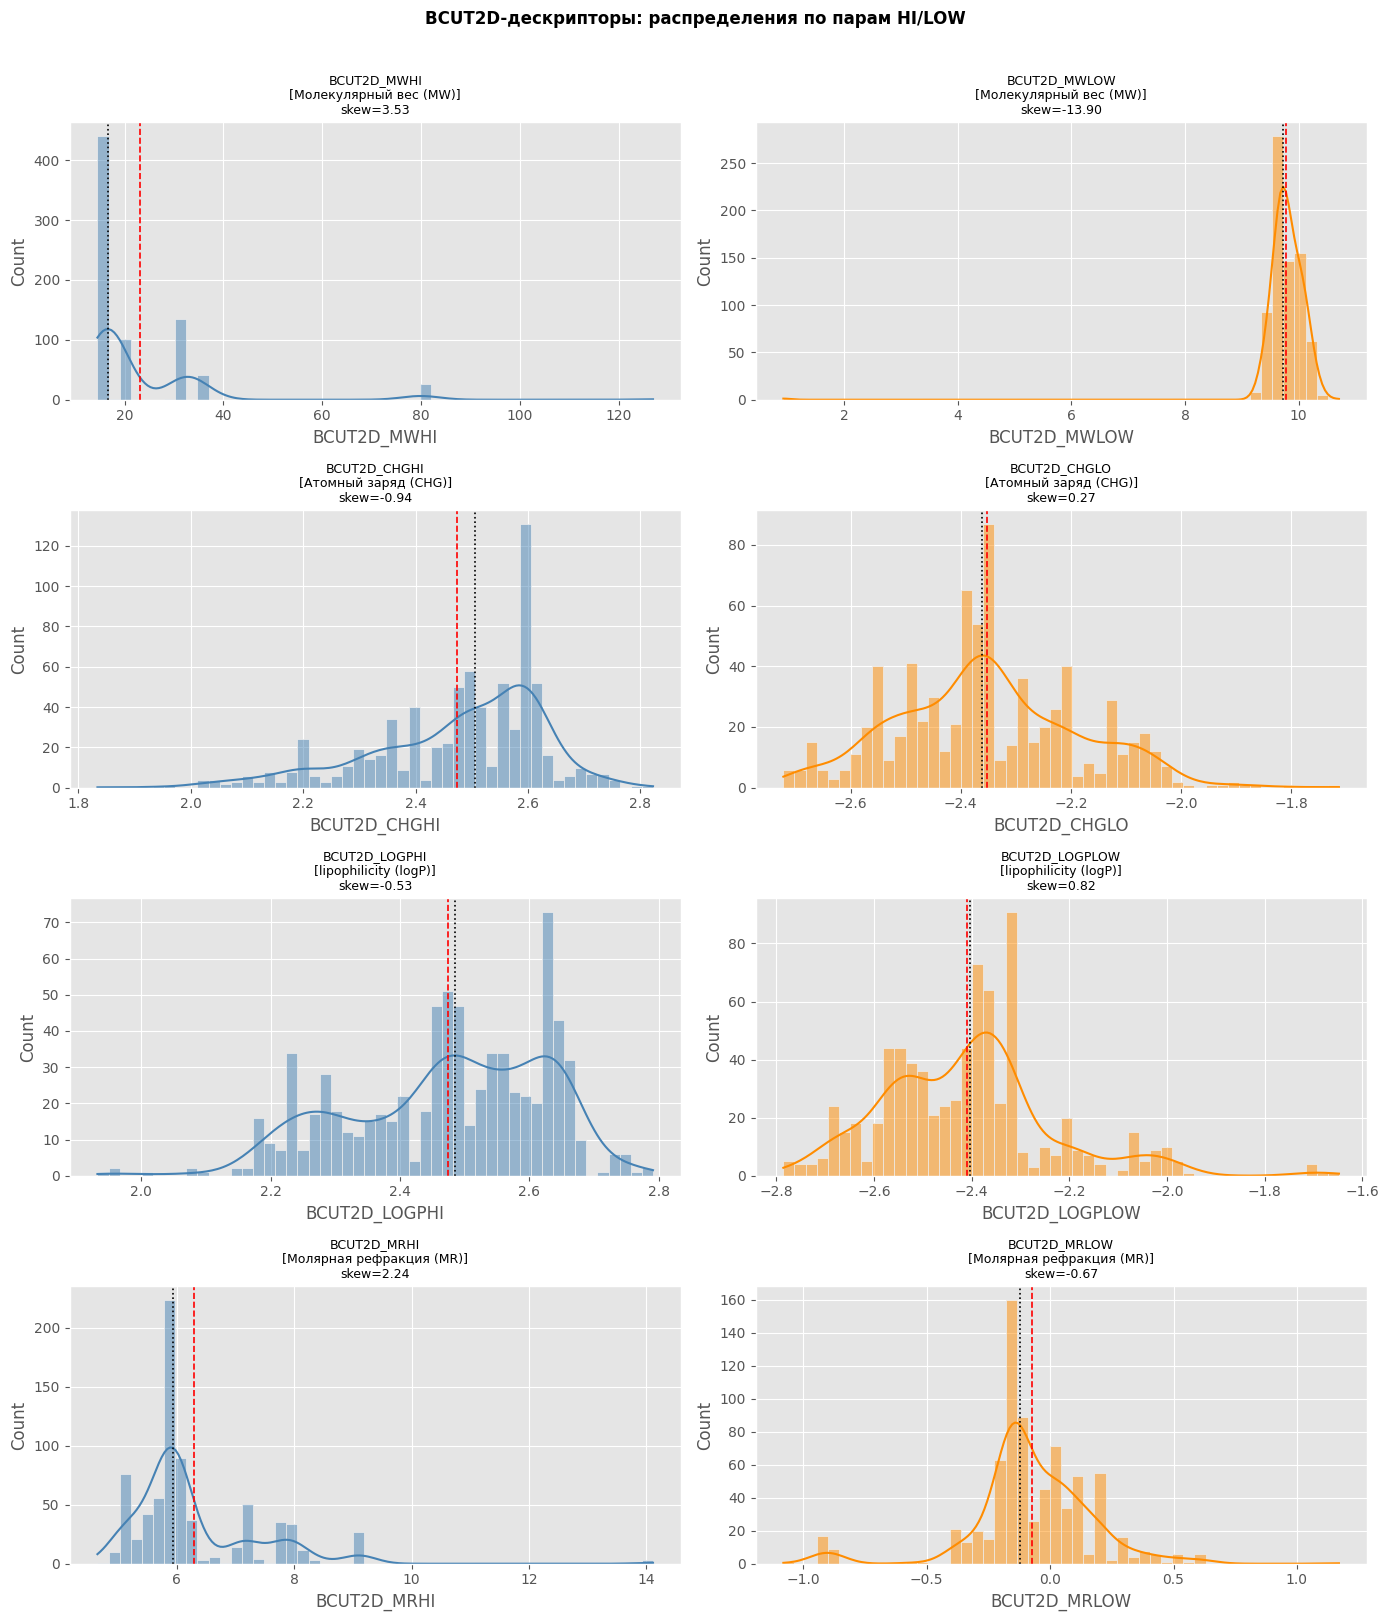

In [53]:
# ── G6: Распределения BCUT2D парами HI/LOW ───────────────────────────────
bcut_pairs = [
    ('BCUT2D_MWHI',   'BCUT2D_MWLOW',  'Молекулярный вес (MW)'),
    ('BCUT2D_CHGHI',  'BCUT2D_CHGLO',  'Атомный заряд (CHG)'),
    ('BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW','lipophilicity (logP)'),
    ('BCUT2D_MRHI',   'BCUT2D_MRLOW',  'Молярная рефракция (MR)'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for row, (hi, lo, label) in enumerate(bcut_pairs):
    for col, feat in enumerate([hi, lo]):
        ax = axes[row, col]
        s = train[feat].dropna()
        sns.histplot(s, bins=50, kde=True, ax=ax,
                     color='steelblue' if col == 0 else 'darkorange')
        ax.axvline(s.mean(),   color='red',   linestyle='--', linewidth=1.2)
        ax.axvline(s.median(), color='black', linestyle=':',  linewidth=1.2)
        ax.set_title(f'{feat}\n[{label}]\nskew={s.skew():.2f}', fontsize=9)
plt.suptitle('BCUT2D-дескрипторы: распределения по парам HI/LOW',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

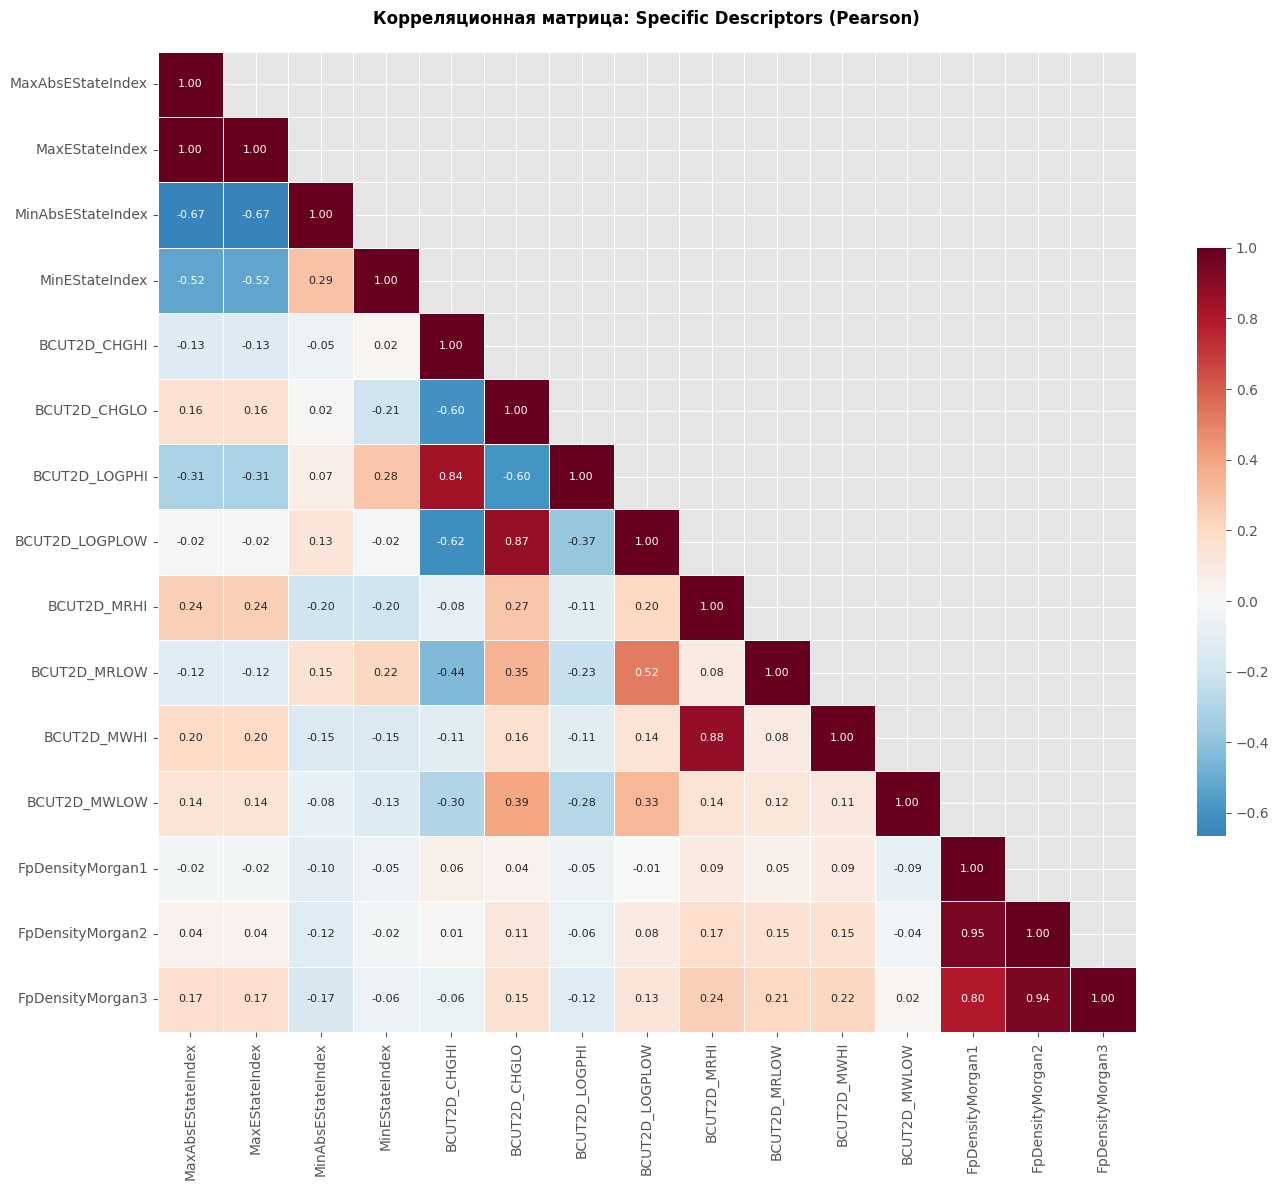

Пары с |r| > 0.8:
  MaxEStateIndex               — MaxAbsEStateIndex           : r=+1.0000
  FpDensityMorgan2             — FpDensityMorgan1            : r=+0.9478
  FpDensityMorgan3             — FpDensityMorgan2            : r=+0.9412
  BCUT2D_MWHI                  — BCUT2D_MRHI                 : r=+0.8786
  BCUT2D_LOGPLOW               — BCUT2D_CHGLO                : r=+0.8679
  BCUT2D_LOGPHI                — BCUT2D_CHGHI                : r=+0.8405
  FpDensityMorgan3             — FpDensityMorgan1            : r=+0.8015


In [54]:
# ── G6: Корреляционный анализ ─────────────────────────────────────────────
corr_feats_g6 = train[SPEC_DESCR].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask_g6 = np.triu(np.ones_like(corr_feats_g6, dtype=bool), k=1)
sns.heatmap(corr_feats_g6, mask=mask_g6, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            cbar_kws={'shrink': 0.6}, annot_kws={'size': 8})
ax.set_title('Корреляционная матрица: Specific Descriptors (Pearson)',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

upper_g6 = corr_feats_g6.where(np.triu(np.ones_like(corr_feats_g6, dtype=bool), k=1))
print('Пары с |r| > 0.8:')
high_g6 = [(c, r, upper_g6.loc[r, c]) for c in upper_g6.columns
           for r in upper_g6.index if abs(upper_g6.loc[r, c]) > 0.8]
if high_g6:
    for c1, c2, v in sorted(high_g6, key=lambda x: -abs(x[2])):
        print(f'  {c1:28s} — {c2:28s}: r={v:+.4f}')
else:
    print('  Нет пар с |r| > 0.8')

In [55]:
# ── G6: Distribution Shift (KS-тест) ─────────────────────────────────────
drift_report_g6 = detect_drift(train, test, SPEC_DESCR)
shifted_g6 = drift_report_g6[drift_report_g6['drift'] == True]
print(f'Признаков со значимым distribution shift: {len(shifted_g6)} / {len(SPEC_DESCR)}')
display(drift_report_g6.sort_values('ks_statistic', ascending=False))

Признаков со значимым distribution shift: 1 / 15


,feature,ks_statistic,p_value,drift
14,FpDensityMorgan3,0.103004,0.034929,True
1,MaxEStateIndex,0.091180,0.082569,False
0,MaxAbsEStateIndex,0.091180,0.082569,False
13,FpDensityMorgan2,0.078945,0.182907,False
4,BCUT2D_CHGHI,0.072362,0.265933,False
7,BCUT2D_LOGPLOW,0.071377,0.277632,False
5,BCUT2D_CHGLO,0.070919,0.287841,False
9,BCUT2D_MRLOW,0.070125,0.296172,False
12,FpDensityMorgan1,0.067169,0.347866,False
11,BCUT2D_MWLOW,0.054887,0.602342,False


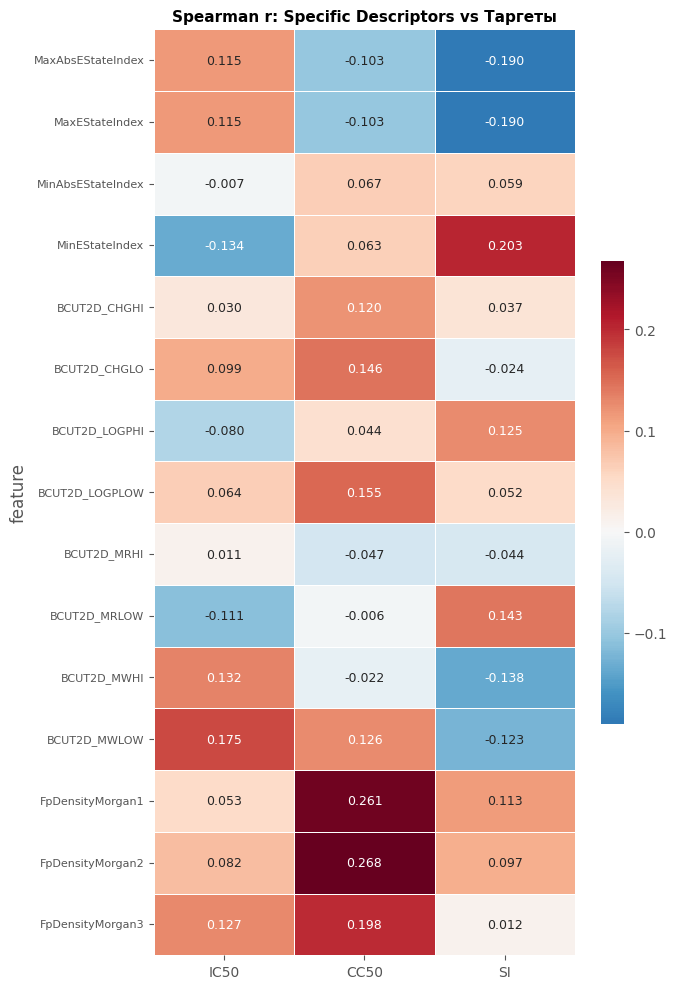

In [56]:
# ── G6: Корреляция с таргетами (Spearman) ────────────────────────────────
sp_rows_g6 = []
for f in SPEC_DESCR:
    mask_g6_sp = train[f].notna()
    row = {'feature': f}
    for t in TARGETS:
        r, p = spearmanr(train.loc[mask_g6_sp, f], train.loc[mask_g6_sp, t])
        row[f'{t}_r'] = round(r, 4)
        row[f'{t}_p'] = round(p, 6)
    sp_rows_g6.append(row)
sp_df_g6 = pd.DataFrame(sp_rows_g6).set_index('feature')

r_cols_g6 = [f'{t}_r' for t in TARGETS]
heat_g6 = sp_df_g6[r_cols_g6].copy()
heat_g6.columns = TARGETS

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(heat_g6, cmap='RdBu_r', center=0, annot=True, fmt='.3f',
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.5}, annot_kws={'size': 9})
ax.set_title('Spearman r: Specific Descriptors vs Таргеты', fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [57]:
# ── G6: Инженерия признаков ───────────────────────────────────────────────
def engineer_specific_SPEC_DESCR(df):
    """Агрегированные признаки на основе Specific Descriptors."""
    d = df.copy()

    # 1. Диапазон EState: мера полярности/неоднородности молекулы
    d['estate_range']       = df['MaxEStateIndex'] - df['MinEStateIndex']
    d['estate_mean_approx'] = (df['MaxEStateIndex'] + df['MinEStateIndex']) / 2

    # 2. BCUT2D: спектральный «размах» по каждому свойству
    d['bcut_mw_range']   = df['BCUT2D_MWHI']   - df['BCUT2D_MWLOW']
    d['bcut_chg_range']  = df['BCUT2D_CHGHI']  - df['BCUT2D_CHGLO']
    d['bcut_logp_range'] = df['BCUT2D_LOGPHI'] - df['BCUT2D_LOGPLOW']
    d['bcut_mr_range']   = df['BCUT2D_MRHI']   - df['BCUT2D_MRLOW']

    # 3. Суммарный спектральный размах — мера «нагруженности» молекулы
    d['bcut_total_range'] = (d['bcut_mw_range'].fillna(0) +
                              d['bcut_chg_range'].fillna(0) +
                              d['bcut_logp_range'].fillna(0) +
                              d['bcut_mr_range'].fillna(0))

    # 4. FpDensity: прирост плотности уникальных фрагментов с ростом радиуса
    d['fp_density_growth_1_2']   = df['FpDensityMorgan2'] - df['FpDensityMorgan1']
    d['fp_density_growth_2_3']   = df['FpDensityMorgan3'] - df['FpDensityMorgan2']
    # Если прирост замедляется — молекула повторяется на большом радиусе
    d['fp_density_deceleration'] = d['fp_density_growth_1_2'] - d['fp_density_growth_2_3']

    return d

ENGINEERED_G6 = [
    'estate_range', 'estate_mean_approx',
    'bcut_mw_range', 'bcut_chg_range', 'bcut_logp_range', 'bcut_mr_range', 'bcut_total_range',
    'fp_density_growth_1_2', 'fp_density_growth_2_3', 'fp_density_deceleration'
]

train = engineer_specific_SPEC_DESCR(train)
test  = engineer_specific_SPEC_DESCR(test)

print('Spearman r (инженерные признаки vs таргеты):')
for feat in ENGINEERED_G6:
    mask_g6e = train[feat].notna()
    line = f'  {feat:35s}:'
    for t in TARGETS:
        r, p = spearmanr(train.loc[mask_g6e, feat], train.loc[mask_g6e, t])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '  '
        line += f'  {t}={r:+.3f}{sig}'
    print(line)

Spearman r (инженерные признаки vs таргеты):
  estate_range                       :  IC50=+0.130***  CC50=-0.079*  SI=-0.196***
  estate_mean_approx                 :  IC50=+0.056    CC50=-0.080*  SI=-0.103**
  bcut_mw_range                      :  IC50=+0.122***  CC50=-0.020    SI=-0.118**
  bcut_chg_range                     :  IC50=-0.034    CC50=-0.036    SI=+0.012  
  bcut_logp_range                    :  IC50=-0.049    CC50=-0.036    SI=+0.027  
  bcut_mr_range                      :  IC50=+0.044    CC50=-0.028    SI=-0.075*
  bcut_total_range                   :  IC50=+0.102**  CC50=-0.015    SI=-0.102**
  fp_density_growth_1_2              :  IC50=+0.121***  CC50=+0.139***  SI=-0.019  
  fp_density_growth_2_3              :  IC50=+0.144***  CC50=-0.051    SI=-0.179***
  fp_density_deceleration            :  IC50=-0.083*  CC50=+0.211***  SI=+0.229***


In [58]:
# ── G6: Удаление дубликата ────────────────────────────────────────────────
SPEC_TO_DROP = ['MaxAbsEStateIndex']
train = train.drop(columns=SPEC_TO_DROP, errors='ignore')
test  = test.drop(columns=SPEC_TO_DROP, errors='ignore')
SPEC_DESCR = [f for f in SPEC_DESCR if f not in SPEC_TO_DROP]

print(f"Удалено: {SPEC_TO_DROP}")
print(f"Индивидуальных G6: {len(SPEC_DESCR)}, инженерных: {len(ENGINEERED_G6)}")

Удалено: ['MaxAbsEStateIndex']
Индивидуальных G6: 14, инженерных: 10


### Выводы G6 — Специфические дескрипторы

| Проблема | Признаки | Действие |
|----------|----------|----------|
| Полный дубликат | `MaxAbsEStateIndex` ≡ `MaxEStateIndex` | Удалён |
| NaN (2 строки train, 1 test) | Все 8 BCUT2D | Заполнены медианой train |
| Distribution shift | `FpDensityMorgan3` (KS p<0.05) | Использовать с осторожностью |
| Высокая мультиколлинеарность | FpDensityMorgan1↔2 (r=0.95), 2↔3 (r=0.94) | Для tree-based — ок |

**Лидеры по Spearman r:** IC50 ← `BCUT2D_MWLOW`, `MinEStateIndex`; CC50 ← `FpDensityMorgan2/3`; SI ← `MinEStateIndex`, `estate_range`.

Добавлено **10 инженерных признаков**. Итого в группе: 14 исходных + 10 инженерных.

## Итоговая сводка

### Преобразования по группам

| Группа | Исходно | Удалено | Добавлено | Итого |
|--------|---------|---------|-----------|-------|
| G1 — Общие молекулярные | 27 | 14 | — | 13 |
| G2 — Электронные / PEOE_VSA | 18 | 3 | 3 (кластерные дамми) | 18 |
| G3 — Топологические | 18* | 11 | — | 7* |
| G4 — VSA поверхностные | 43 | 5 | 12 (агрегаты) | 50 |
| G5 — Функциональные группы | 85 | 36 | — | 49 |
| G6 — EState / BCUT2D / FpDensity | 15 | 1 | 10 (агрегаты) | 24 |

*\*G3 пересекается с G1 по кольцевым дескрипторам; часть удалена ещё на шаге G1.*

### Общие наблюдения

- **Пропуски:** 4 признака G2 (зарядовые, 2 NaN каждый) и 8 признаков G6 (BCUT2D, 2 NaN) — заполнены медианой train.
- **Distribution shift:** значимый дрифт обнаружен только у `FpDensityMorgan3` (G6). Остальные группы стабильны между train и test.
- **Мультиколлинеарность:** устранена в G1 (кольцевые дескрипторы) и G3 (Chi/Kappa индексы). В G4 и G6 допустима для tree-based моделей.
- **Инженерия признаков:** G2 добавил кластерную сегментацию по электронной плотности (ANOVA значимо); G4 и G6 добавили физически интерпретируемые агрегаты.

# Ключевые выводы
## Работа с проблемными признаками.
### 1. Пары с корреляцией > 0.95

#### G1: все дублирующие пары (MolWt–ExactMolWt, MolWt–HeavyAtomMolWt и т.д.) удалены. MolWt, ExactMolWt, HeavyAtomMolWt, LabuteASA, HeavyAtomCount, NumValenceElectrons исключены. NHOHCount и NumHDonors (0.98) также удалены. Оставлены только признаки, не образующие пар >0.95.

#### G2: пара MaxPartialCharge–MinAbsPartialCharge (0.975) разрешена удалением MinAbsPartialCharge. MinPartialCharge и MaxAbsPartialCharge удалены как почти константные и зеркальные.

#### G3: все пары Chi/Kappa-индексов >0.95 обработаны — оставлены только Chi0v, Chi2v, Chi4v, Kappa3. Проверка после удаления: пар >0.95 не осталось.

#### G4: оставшиеся пары с корреляцией >0.9 (например, SlogP_VSA11–SMR_VSA9 0.908) сознательно не удалялись, так как для деревьев это не критично, а для линейных моделей мы предложили PCA в улучшенном датасете.

#### G5: иерархическая кластеризация на основе Spearman |r| > 0.8 с выбором лучшего представителя кластера эффективно устраняет избыточность.

#### G6: MaxAbsEStateIndex ≡ MaxEStateIndex удалён. Оставлены FpDensityMorgan1 и FpDensityMorgan2 (r=0.95) — для деревьев допустимо, для линейных можно было бы дополнительно применить PCA, но в улучшенном датасете мы удалили FpDensityMorgan3 (дрейф) и не трогали остальные, что приемлемо.

### 2. Дрифт (KS-тест)

#### В G1 дрифт был у NumValenceElectrons и LabuteASA, но оба признака удалены.

#### В остальных группах значимый дрейф обнаружен только у FpDensityMorgan3 (p ≈ 0.035). В улучшенном датасете мы его исключили. Базовый датасет оставляет его для экспериментов — корректно.

#### Остальные признаки, включая MaxEStateIndex (p=0.083), не имеют статистически значимого сдвига.

### 3. Константные и почти константные признаки

#### NumRadicalElectrons (G1) — удалён.

#### SMR_VSA8, SlogP_VSA9 (100% нулей), SMR_VSA2 (98.9%), EState_VSA11 (97.2%) — удалены.

#### В G5 VarianceThreshold(0.01) удалил признаки, встречающиеся реже чем у 1% молекул.

#### Все пропуски (G2, G6) заполнены медианой.

#### Таким образом, все выявленные проблемы учтены.

## Сильные стороны текущего датасета:
### Многогрупповая очистка: последовательно обработаны все шесть групп, удалены константные, почти константные и дублирующие признаки.

### Инженерия признаков:

#### G2 – кластеры PEOE_VSA (ANOVA-подтверждённые) добавлены как дамми.

#### G4 – агрегаты по семействам VSA (общая площадь, полярность, гидрофобность, дисперсия).

#### G6 – спектральные диапазоны BCUT2D, производные FpDensity.

#### G5 – иерархическая кластеризация fr-признаков с отбором лучших по Spearman r.

### Обработка пропусков: медианная импутация для зарядовых и BCUT2D.

### Контроль дрифта: KS-тесты показали отсутствие значимых сдвигов между train и test (кроме FpDensityMorgan3).

### Итоговая размерность: 751×N, где N ≈ 13+18+7+50+49+24 = 161 признак (плюс index). Это умеренное количество для 750 объектов.

#Дополнительно сделаем:
### Логарифмирование таргетов
#### Распределения IC50, CC50, SI сильно право-скошены. Для регрессии (особенно линейной) желательно предсказывать логарифмы, что стабилизирует дисперсию и уменьшает влияние выбросов. Добавим log_IC50, log_CC50, log_SI.

### Обработка выбросов в признаках
#### В EDA G2/G4/G6 отмечены экстремальные значения (PEOE_VSA4, VSA-бины, EState-индексы). Для линейных моделей необходима винзоризация (1 % / 99 %) или RobustScaler. Создадим масштабированную версию признаков с винзоризацией и стандартизацией.

### Масштабирование для линейных моделей
#### После винзоризации применим StandardScaler (или RobustScaler) ко всем непрерывным признакам. Бинарные признаки (fr_*, кластерные дамми) оставим без изменений. Для деревьев масштабирование не требуется, оставим исходные значения.

### Удаление признака с дрифтом
#### FpDensityMorgan3 показал значимый KS-тест. Хотя деревья могут справиться, для повышения надёжности можно исключить его из линейных моделей. Удалим его из масштабированного набора, но оставим в исходном для экспериментов.

### Дополнительная проверка мультиколлинеарности
#### В G4 остались корреляции между отдельными VSA-бинами (до 0.96). Для линейных моделей можно применить PCA на группе VSA, либо удалить один из каждой высококоррелированной пары. Однако агрегированные признаки уже частично решают эту проблему. Добавим PCA-компоненты для VSA-бинов (после масштабирования) как дополнительную опцию, но не в базовый датасет.

### Сохраним согласованность train/test
#### Все преобразования (винзоризация, масштабирование, импутация) делаем только на train и применяем к test.

## Создадим финальные датасеты для дальнейшего тестирования моделей:
### 1. Датасет без масштабирования
### 2. Датасет (базовый) с масштабированием (StandardScaler)
###   - бинарные признаки не трогаем
###   - непрерывные: винзоризация (1%/99%) + StandardScaler
### 3. Датасет (улучшеный) (удаление дрейфа, PCA на VSA, RobustScaler)


In [59]:
# Все признаки, оставшиеся в датафрейме (без таргетов и 'index')
FEATURE_COLS = [c for c in train.columns if c not in TARGETS and c != 'index']

print(f"Итоговое число признаков: {len(FEATURE_COLS)}")
print(f"  G1 (общие молекулярные):   {len(GENERAL_MOLECULAR_PROPERTIES)}")
print(f"  G2 (электронные):          {len(ELECTRONIC_FEATURES)}")
print(f"  G3 (топологические):       {len(TOPOLOGICAL_FEATURES)}")
print(f"  G4 (VSA исходные):         {len(FEATURES_VSA)},  инженерные: {len(ENGINEERED_VSA)}")
print(f"  G5 (fr_*):                 {len(FR_FINAL)}")
print(f"  G6 (специфические):        {len(SPEC_DESCR)},  инженерные: {len(ENGINEERED_G6)}")
print()

assert len(FEATURE_COLS) == len(set(FEATURE_COLS)), "Дублирующиеся колонки!"
print("Дублирующихся колонок нет ✓")
print(f"Пропусков в train: {train[FEATURE_COLS].isnull().sum().sum()}")
print(f"Пропусков в test:  {test[FEATURE_COLS].isnull().sum().sum()}")

Итоговое число признаков: 165
  G1 (общие молекулярные):   13
  G2 (электронные):          18
  G3 (топологические):       18
  G4 (VSA исходные):         38,  инженерные: 12
  G5 (fr_*):                 49
  G6 (специфические):        14,  инженерные: 10

Дублирующихся колонок нет ✓
Пропусков в train: 0
Пропусков в test:  0


# 1. Итоговый датасет без преобразований признаков

In [62]:
# Финальные матрицы для моделирования
X_train = train[FEATURE_COLS]
y_train = train[TARGETS]
X_test  = test[FEATURE_COLS]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")

print("\nСтатистика таргетов:")
display(y_train.describe().round(2))

# Заглушка для сабмита: X_test.index — индексы тестовых объектов
print(f"\nИндексы тестовых объектов (первые 5): {list(X_test.index[:5])}")

X_train: (751, 165)
y_train: (751, 3)
X_test:  (250, 165)

Статистика таргетов:


,IC50,CC50,SI
count,751.00,751.00,751.00
mean,204.54,577.43,89.15
std,370.37,641.52,788.88
min,0.00,0.70,0.01
25%,13.22,100.00,1.50
50%,44.07,376.58,4.00
75%,206.79,877.51,17.37
max,4095.19,4538.98,15620.60



Индексы тестовых объектов (первые 5): [0, 1, 2, 3, 4]


# Итоговый датасет - базовый.
Базовый датасет включает:

X_train_raw = те же признаки, что и в X_train.

X_train_scaled = те же признаки, но непрерывные подвергнуты винзоризации (1%/99%) и StandardScaler; бинарные оставлены без изменений.

Добавлены логарифмированные таргеты y_train_log.
То есть базовый датасет не отличается по составу признаков от финального набора EDA, он лишь добавляет готовый масштабированный вариант и логарифмированные таргеты для удобства моделирования.

In [63]:
# Финальный датасет для моделирования (базовый)
# 1. Определим типы признаков: бинарные и непрерывные
binary_feats = [f for f in FEATURE_COLS if train[f].nunique() == 2]
continuous_feats = [f for f in FEATURE_COLS if f not in binary_feats]
continuous_feats = [f for f in continuous_feats if f != 'index']

print(f"Бинарных признаков: {len(binary_feats)}")
print(f"Непрерывных признаков: {len(continuous_feats)}")

# 2. Винзоризация на основе train (границы 1% и 99%)
winsor_bounds = {}
for feat in continuous_feats:
    lower = np.percentile(train[feat], 1)
    upper = np.percentile(train[feat], 99)
    winsor_bounds[feat] = (lower, upper)

def apply_winsorization(df, bounds):
    df_wins = df.copy()
    for feat, (lo, hi) in bounds.items():
        df_wins[feat] = df_wins[feat].clip(lo, hi)
    return df_wins

train_wins = apply_winsorization(train[continuous_feats], winsor_bounds)
test_wins  = apply_winsorization(test[continuous_feats], winsor_bounds)

# 3. Масштабирование непрерывных признаков (StandardScaler)
scaler = StandardScaler()
train_scaled_cont = pd.DataFrame(scaler.fit_transform(train_wins),
                                 columns=continuous_feats,
                                 index=train_wins.index)
test_scaled_cont  = pd.DataFrame(scaler.transform(test_wins),
                                 columns=continuous_feats,
                                 index=test_wins.index)

# 4. Объединяем с бинарными признаками (без изменений)
X_train_raw = train[FEATURE_COLS].copy()
X_test_raw  = test[FEATURE_COLS].copy()

X_train_scaled = pd.concat([train_scaled_cont, train[binary_feats]], axis=1)
X_test_scaled  = pd.concat([test_scaled_cont,  test[binary_feats]], axis=1)

# Убедимся, что порядок колонок совпадает с FEATURE_COLS
X_train_scaled = X_train_scaled[FEATURE_COLS]
X_test_scaled  = X_test_scaled[FEATURE_COLS]

# 5. Логарифмированные таргеты
y_train_raw = train[TARGETS].copy()
y_train_log = np.log1p(y_train_raw)
y_train_log.columns = [f'log_{t}' for t in TARGETS]

print("Финальные размеры (базовый датасет):")
print(f"X_train_raw:    {X_train_raw.shape}")
print(f"X_test_raw:     {X_test_raw.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"y_train_log:    {y_train_log.shape}")

# Проверка: отсутствие пропусков
assert X_train_scaled.isnull().sum().sum() == 0
assert X_test_scaled.isnull().sum().sum() == 0
print("Пропусков в финальных данных нет ✓")

Бинарных признаков: 17
Непрерывных признаков: 148
Финальные размеры (базовый датасет):
X_train_raw:    (751, 165)
X_test_raw:     (250, 165)
X_train_scaled: (751, 165)
X_test_scaled:  (250, 165)
y_train_log:    (751, 3)
Пропусков в финальных данных нет ✓


# Итоговый датасет 2 (улучшенный) – с удалением дрейфа, PCA для VSA и RobustScaler

Улучшенный датасет 2 делает:

Удаляет FpDensityMorgan3 (дрейф).

Заменяет все исходные VSA-бины на PCA-компоненты, объясняющие 95% дисперсии (снижает мультиколлинеарность и размерность).

Применяет RobustScaler вместо StandardScaler (лучше работает с выбросами).

Оставляет бинарные признаки нетронутыми.



In [65]:
# Финальный датасет для моделирования (улучшеный)

# Копируем очищенные train/test (из объединённого EDA)
train_imp = train.copy()
test_imp  = test.copy()

# 1. Удаление признака с дрейфом
dropped_drift = 'FpDensityMorgan3'
if dropped_drift in train_imp.columns:
    train_imp.drop(columns=dropped_drift, inplace=True)
    test_imp.drop(columns=dropped_drift, inplace=True)
    print(f"Удалён дрейфующий признак: {dropped_drift}")

# 2. Определяем группы признаков
# все бинарные (включая fr_*, дамми кластеров)
binary_cols = [c for c in train_imp.columns
               if c != 'index' and c not in TARGETS and train_imp[c].nunique() == 2]

# непрерывные (оставшиеся)
cont_cols = [c for c in train_imp.columns
             if c != 'index' and c not in TARGETS and c not in binary_cols]

# VSA‑бины (индивидуальные, без агрегатов)
vsa_bin_patterns = ['SMR_VSA', 'SlogP_VSA', 'EState_VSA', 'VSA_EState']
vsa_bin_cols = [c for c in cont_cols if any(pat in c for pat in vsa_bin_patterns)
                and not c.startswith('vsa_')]   # исключаем агрегированные vsa_*
other_cont_cols = [c for c in cont_cols if c not in vsa_bin_cols]

print(f"VSA-бинов для PCA: {len(vsa_bin_cols)}")
print(f"Других непрерывных: {len(other_cont_cols)}")
print(f"Бинарных: {len(binary_cols)}")

# --- 3. Винзоризация всех непрерывных (1% / 99%) ---
winsor_bounds_imp = {}
for feat in cont_cols:
    lower = np.percentile(train_imp[feat], 1)
    upper = np.percentile(train_imp[feat], 99)
    winsor_bounds_imp[feat] = (lower, upper)

def apply_winsorization_imp(df, bounds):
    df_w = df.copy()
    for feat, (lo, hi) in bounds.items():
        df_w[feat] = df_w[feat].clip(lo, hi)
    return df_w

train_wins_imp = apply_winsorization_imp(train_imp[cont_cols], winsor_bounds_imp)
test_wins_imp  = apply_winsorization_imp(test_imp[cont_cols], winsor_bounds_imp)

# 4. RobustScaler для всех непрерывных (перед PCA)
robust_scaler = RobustScaler()
train_cont_scaled = pd.DataFrame(robust_scaler.fit_transform(train_wins_imp),
                                 columns=cont_cols, index=train_wins_imp.index)
test_cont_scaled  = pd.DataFrame(robust_scaler.transform(test_wins_imp),
                                 columns=cont_cols, index=test_wins_imp.index)

# 5. PCA на VSA-бинах (замена исходных VSA-бинов)
# Обучаем PCA на train, оставляем компоненты, объясняющие 95% дисперсии
pca = PCA(n_components=0.95, random_state=42)
train_vsa_pca = pca.fit_transform(train_cont_scaled[vsa_bin_cols])
test_vsa_pca  = pca.transform(test_cont_scaled[vsa_bin_cols])

# Имена для PCA-компонент
pca_cols = [f'VSA_PC{i+1}' for i in range(train_vsa_pca.shape[1])]
train_vsa_pca_df = pd.DataFrame(train_vsa_pca, columns=pca_cols, index=train_imp.index)
test_vsa_pca_df  = pd.DataFrame(test_vsa_pca, columns=pca_cols, index=test_imp.index)
print(f"PCA компонент (95% дисперсии): {len(pca_cols)} (исходных VSA-бинов было {len(vsa_bin_cols)})")

# 6. Собираем улучшенный датасет
# непрерывные: остальные (не VSA) + PCA-компоненты
X_train_improved = pd.concat([
    train_cont_scaled[other_cont_cols],
    train_vsa_pca_df,
    train_imp[binary_cols]
], axis=1)

X_test_improved = pd.concat([
    test_cont_scaled[other_cont_cols],
    test_vsa_pca_df,
    test_imp[binary_cols]
], axis=1)

# Убедимся, что порядок колонок не нарушен (он не важен для моделей, но для порядка)
# Итоговый список колонок
improved_cols = other_cont_cols + pca_cols + binary_cols
X_train_improved = X_train_improved[improved_cols]
X_test_improved  = X_test_improved[improved_cols]

# 7. Логарифмированные таргеты
y_train_imp_raw = train_imp[TARGETS].copy()
y_train_imp_log = np.log1p(y_train_imp_raw)
y_train_imp_log.columns = [f'log_{t}' for t in TARGETS]

print("\nФинальные размеры (улучшенный датасет):")
print(f"X_train_improved: {X_train_improved.shape}")
print(f"X_test_improved:  {X_test_improved.shape}")
print(f"y_train_imp_log:  {y_train_imp_log.shape}")

# Проверка на пропуски
assert X_train_improved.isnull().sum().sum() == 0
assert X_test_improved.isnull().sum().sum() == 0
print("Пропусков в улучшенном датасете нет ✓")

Удалён дрейфующий признак: FpDensityMorgan3
VSA-бинов для PCA: 38
Других непрерывных: 109
Бинарных: 17
PCA компонент (95% дисперсии): 4 (исходных VSA-бинов было 38)

Финальные размеры (улучшенный датасет):
X_train_improved: (751, 130)
X_test_improved:  (250, 130)
y_train_imp_log:  (751, 3)
Пропусков в улучшенном датасете нет ✓


# Выводы по трём датасетам
## №1 – Без масштабирования:	все отобранные признаки (без масштабирования)	только очистка, удаление, добавление дамми.
## Для каких моделей подойдет: Градиентный бустинг, случайный лес, CatBoost
## №2 – Базовый масштабированный: те же признаки	винзоризация (1%/99%) + StandardScaler для непрерывных; бинарные без изменений.
## Для каких моделей подойдет:	Линейные модели (Ridge, Lasso, ElasticNet), нейронные сети
## №3 – Улучшенный: удалён FpDensityMorgan3; VSA-бины заменены на PCA-компоненты; оставлены прочие непрерывные и все бинарные	винзоризация + RobustScaler + PCA.
## Для каких моделей подойдет:	Линейные модели (снижена размерность и устранена мультиколлинеарность)

## Возможные дополнительные улучшения:

### 1. Обработка оставшейся мультиколлинеарности

#### FpDensityMorgan1 и FpDensityMorgan2 (r=0.95) в улучшенном датасете сохранены. Для линейных моделей можно либо применить PCA к этим двум признакам, либо оставить один. Можно добавить опцию: создать FpDensity_pc1 из двух признаков и включить её вместо исходных.

### 2. Стабильность PCA
####Убедитесь, что PCA, обученный на train, хорошо объясняет дисперсию и на test. Можно вывести explained_variance_ratio_ и проверить кумулятивную сумму. При необходимости увеличить долю до 0.99.

### 3. Отбор признаков
#### После создания датасетов можно провести быстрый отбор признаков по важности (например, с помощью SelectKBest или важности из LightGBM) и оставить топ-100, чтобы снизить шум.

### 4. Дополнительные бинарные флаги
#### Для наиболее важных непрерывных признаков с выбросами можно создать флаги «выброс» (например, PEOE_VSA4 > Q3+1.5*IQR). Это может помочь моделям.

### 5. Кросс-валидация с учётом scaffold
#### Если будут добавлены SMILES и выделены скаффолды, стоит применить GroupKFold по скаффолдам — это реалистичнее оценит способность модели обобщаться на новые хемотипы.

### 6. Ансамблирование
#### Комбинируйте предсказания моделей, обученных на разных датасетах: например, LightGBM на raw + Ridge на scaled. Мета-модель (простая линейная регрессия) может дать дополнительный прирост.

### 7. Запуск baseline

#### Линейный: Ridge с подбором alpha по логарифмической сетке на датасете №2 (или №3).

#### Деревья: LightGBM с objective='regression', metric='rmse', обучение на логарифмированных таргетах датасета №1.

#### Сравнить RMSE на кросс-валидации для каждого таргета отдельно и общий средний RMSE.